# Description

Drafts for the finalized versions of the paper figures

# Load analysis functions

In [118]:
%run ..../imports.ipynb
%run ..../analysisScripts/snotelAnalysisFunctions.ipynb

# Figure 1

Panel showing station locations, scatter points colored by climatological peak SWE (calculated in stationOverview.ipynb)

Panel showing peak SWE histogram of the SWE climatological seasonal cycles from all stations (calculated in sweUniversal.ipynb)

In [111]:
### Load Peak SWE data ###
pathToLoad = '...../data/figureData'
peakSWEData = np.load(pathToLoad + '/figure1MaxSWE.npz')

lats = peakSWEData['lats']
lons = peakSWEData['lons']
metrics = peakSWEData['peakSWE']

### Load the SWE timeseries data ###
sweTimeSeriesData = np.load(pathToLoad + '/figure1SWECurvesDim_Climatology.npz')
Xmean = sweTimeSeriesData['Xmean']
Ymean = sweTimeSeriesData['Ymean']
tt = sweTimeSeriesData['tt']
bb = sweTimeSeriesData['bb']
allHist = sweTimeSeriesData['allHist']

/tmp/ipykernel_142120/3378032681.py:14: RuntimeWarning: divide by zero encountered in log2
  c = ax1.pcolormesh(tt,bb,np.log2(allHist.T),cmap=cmap,norm=norm)#np.append([],[2**i for i in range (2,8,1)]))
/tmp/ipykernel_142120/3378032681.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


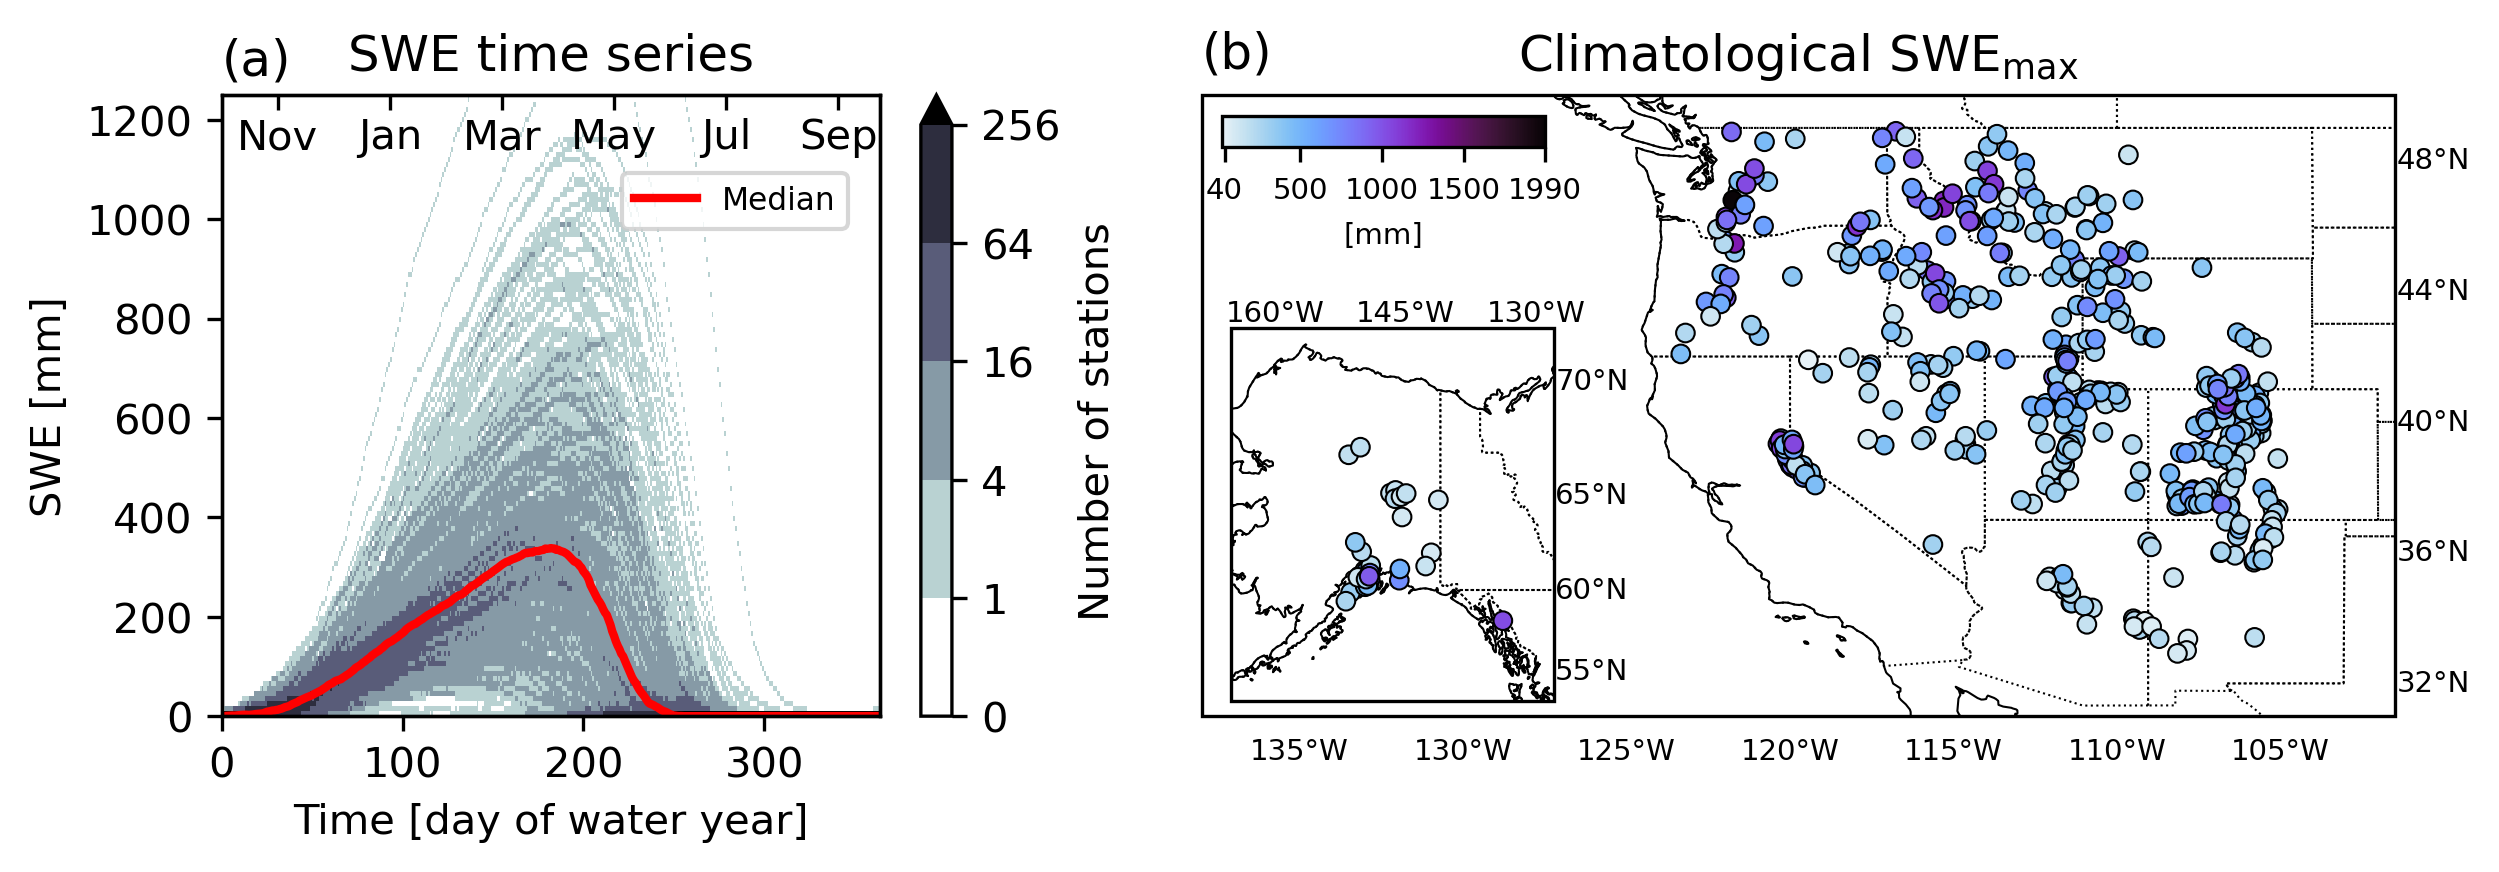

In [133]:
fig = plt.figure(figsize=(8.5,3),dpi=300)
gs = GridSpec(1, 2, width_ratios=[1,1.5])

## SWE Time Series Histogram ##

ax1 = fig.add_subplot(gs[0])
plt.subplots_adjust(hspace=-8)

levels = MaxNLocator(nbins=5).tick_values(-1, 8)
cmap = plt.colormaps['bone_r']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False,extend='max')


c = ax1.pcolormesh(tt,bb,np.log2(allHist.T),cmap=cmap,norm=norm)#np.append([],[2**i for i in range (2,8,1)]))
cbar = plt.colorbar(c,label='Number of stations')
cbar.ax.set_yticklabels(['0']+[str(round(2**i)) for i in levels[1:]])
ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax1.set_ylabel(r'SWE [mm]')
ax1.set_xlabel('Time [day of water year]')
ax1.set_ylim([0,1250])
ax1.set_xticks(np.arange(0,400,100))
ax1.set_xlim([0,364])

ax2 = ax1.twiny()
ax2.set_xlim([0,364])
ax2.set_xticks(np.arange(0,359,62)+31)
ax2.set_xticklabels(['Nov','Jan','Mar','May','Jul','Sep'],rotation=0);
ax2.tick_params(axis="x",direction="in",pad=-15)

ax1.legend(loc='upper right', bbox_to_anchor=(0.975, 0.9),fontsize=7.5)
ax1.set_title('SWE time series')
ax1.text(0,1290,'(a)',fontsize=12);


#############################################
## Max SWE plot ##

# Continental US Stations #
ax0 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())

# Add coastlines
ax0.coastlines(linewidth=0.5,zorder=-1)

# Add U.S. state borders
ax0.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}

cmap = cmr.get_sub_cmap('cmr.voltage_r', 0.05, 0.95)

scatterSize = 20

sc = ax0.scatter(lons,lats,scatterSize,
                 c=metrics,cmap=cmap,edgecolor='k',linewidth=.5,zorder=0)

# Alaska stations #
axins = ax0.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
axins.scatter(lons,lats,scatterSize,
              c=metrics,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0)
axins.coastlines(linewidth=0.5,zorder=-1)
axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
lon1, lon2, lat1, lat2 = -165, -128, 53, 72
axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.bottom_labels = False
gl.left_labels = False
#gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}


cbarTicks = np.array([40,500,1000,1500,1990])

# add colorbar
cbaxes = inset_axes(ax0,
    width="27%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",
)
cbaxes.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(sc,cax=cbaxes,#label='Climatological Peak SWE (mm)'
            orientation='horizontal')
cbar.set_ticks(cbarTicks)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('[mm]',size=7)

ax0.set_title(r'Climatological SWE$_\mathdefault{max}$')

lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
ax0.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

ax0.text(-138,50.85,'(b)',fontsize=12)

#############################################


plt.tight_layout()

saveFigBool = 0
if saveFigBool:
    plt.savefig(f'...../finalizedFigures/figure1_stationSWEClim_timeseries.pdf')

# Figure 2: $k(t)$

Show the time series of $k(t)$, the degree-day factor. Values are computed in deduceKEmpirically.ipynb

In [27]:
### Load data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
kData = np.load(pathToLoad + '/figure2_k.npz',allow_pickle=True)

datesForPlot = kData['datesForPlot']
binCenters = kData['binCenters']
hist2d = kData['hist2d']

## Also load the median k(t) ##
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
kMedian = np.load(pathToLoad + '/figure2_kMedian.npy')

## Load the station count data ##
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
kCount = np.load(pathToLoad + '/figure2_kCount.npz')
numberOfMeltyStations = kCount['numberOfMeltyStations']

In [28]:
## Smooth kMedian ##
# 30-day running mean
kMedianSmooth = movingAverage(np.append(np.append(kMedian,kMedian),kMedian),30)[366:366+366]

/tmp/ipykernel_918/2319712464.py:11: RuntimeWarning: divide by zero encountered in log
  ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
/tmp/ipykernel_918/2319712464.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
/tmp/ipykernel_918/2319712464.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)


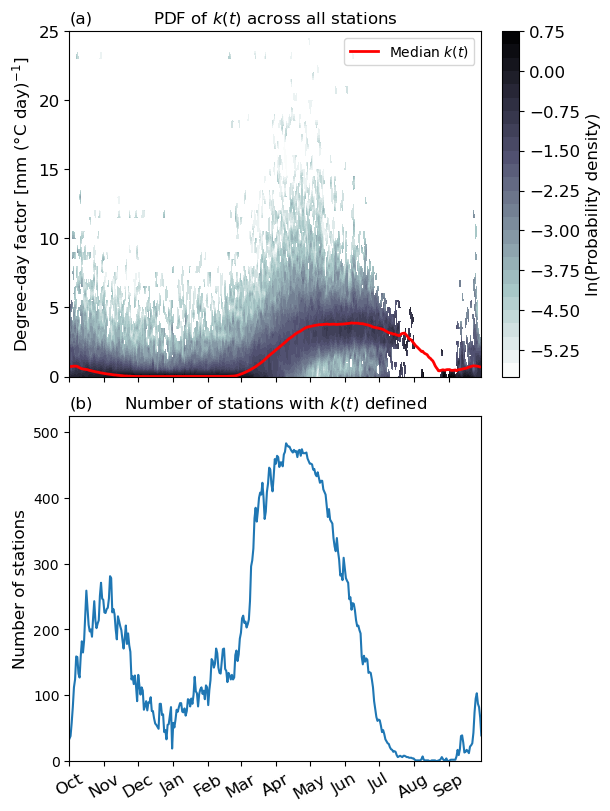

In [29]:
datedate,binbin = np.meshgrid(datesForPlot,binCenters)

### Set up figure ###
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True, layout='constrained')
figFontSize = 12
ax0=axs[0]
ax1=axs[1]

## Plot histogram of k across all stations ##
cmap = 'bone_r'#cmr.get_sub_cmap('cmr.neutral', 0.05, 0.95)
ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
ax0.tick_params(axis='x', labelrotation=0)
ax0.tick_params(axis='both', labelsize=figFontSize)
cbar = plt.colorbar(ctf)
cbar.ax.tick_params(labelsize=figFontSize)
cbar.set_label(label='ln(Probability density)',fontsize=figFontSize)
ax0.set_ylabel(r'Degree-day factor [mm $(\degree \text{C day})^{-1}$]',fontsize=figFontSize)
ax0.set_ylim([0,25])

ax0.plot(datesForPlot,kMedianSmooth,linewidth=2,c='r',label=r'Median $k(t)$')
ax0.set_title('PDF of $k(t)$ across all stations',fontsize=figFontSize)
ax0.text(datetime.datetime(1999, 10, 1, 0, 0),25.6,'(a)',fontsize=figFontSize)
ax0.legend()

## Plot count of stations contributing to median on each date ##
ax1 = plt.subplot(2,1,2)
ax1.plot(datesForPlot,numberOfMeltyStations)
ax1.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
ax1.tick_params(axis='x', labelrotation=30)
ax1.set_xlim([min(datesForPlot),max(datesForPlot)])
#ax1.set_ylim([0,850])
ax1.set_ylabel(r'Number of stations',fontsize=figFontSize)
ax1.set_title(fr'Number of stations with $k(t)$ defined',fontsize=figFontSize)
ax1.set_ylim([0,525])
ax1.text(datetime.datetime(1999, 10, 1, 0, 0),537,'(b)',fontsize=figFontSize)

saveFigBool = False
if saveFigBool:
    plt.savefig('..../figure2_k.pdf',bbox_inches='tight')

# Figure 3

$R^2$ values between model and observations. Data for this figure is calculated in modelHeirarchy.ipynb.

In [ ]:
plotThis = False

if plotThis:
    fig = plt.figure(figsize=(10,10),dpi=300)
    gs = GridSpec(2, 2)

    figFontSize = 12

    ########################################################

    #### Time-dependent model vs obs climatological max SWE ####
    ax0 = fig.add_subplot(gs[0])

    xData = timeDepStation
    yData = obsStation
    ax0.scatter(xData,yData,20,label='Station',edgecolor='k',linewidth=.25)
    ax0.set_ylabel('Observations [mm]',fontsize=figFontSize)
    ax0.set_xlabel('Time-dependent model [mm]',fontsize=figFontSize)
    ax0.axis('square')
    ax0.set_xlim([0,2100])
    ax0.set_ylim([0,2100])
    ax0.set_title('Climatological max SWE',fontsize=figFontSize)

    ## Plot 1-1 line ##
    ax0.plot(np.arange(0,2100),np.arange(0,2100),c='#114060',label='1-1 line')
    thisR2 = R2_from1to1(xData,yData)
    ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
    ax0.legend(fontsize=figFontSize)

    ax0.tick_params(axis='both', labelsize=figFontSize)

    ax0.text(0,2150,'(a)',fontsize=figFontSize)

    ########################################################

    #### Time-dependent model vs obs deviation from climatological max SWE ####
    ax1 = fig.add_subplot(gs[1])
    xData = timeDepWY
    yData = obsWY
    ax1.scatter(xData,yData,20,c='#7570b3',label='Water year',edgecolor='k',linewidth=.25)
    ax1.set_ylabel('Observations [mm]',fontsize=figFontSize)
    ax1.set_xlabel('Time-dependent model [mm]',fontsize=figFontSize)
    ax1.axis('square')
    ax1.set_xlim([-1100,1800])
    ax1.set_ylim([-1100,1800])
    ax1.set_title('Annual max SWE anomaly',fontsize=figFontSize)

    ## Plot 1-1 line ##
    ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#403c71',label='1-1 line')
    thisR2 = R2_from1to1(xData,yData)
    ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
    ax1.legend(fontsize=figFontSize)

    ax1.tick_params(axis='both', labelsize=figFontSize)
    ax1.text(-1100,1875,'(b)',fontsize=figFontSize)

    ########################################################

    #### Analytic model vs obs climatological max SWE ####
    ax0 = fig.add_subplot(gs[2])

    xData = analyticStation
    yData = obsStation
    ax0.scatter(xData,yData,20,label='Station',edgecolor='k',linewidth=.25)
    ax0.set_ylabel('Observations [mm]',fontsize=figFontSize)
    ax0.set_xlabel('Analytic model [mm]',fontsize=figFontSize)
    ax0.axis('square')
    ax0.set_xlim([0,2100])
    ax0.set_ylim([0,2100])
    ax0.set_title('Climatological max SWE',fontsize=figFontSize)

    ## Plot 1-1 line ##
    ax0.plot(np.arange(0,2100),np.arange(0,2100),c='#114060',label='1-1 line')
    thisR2 = R2_from1to1(xData,yData)
    ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
    ax0.legend(fontsize=figFontSize)

    ax0.tick_params(axis='both', labelsize=figFontSize)

    ax0.text(0,2150,'(c)',fontsize=figFontSize)

    ########################################################

    #### Analytic model vs obs deviation from climatological max SWE ####
    ax1 = fig.add_subplot(gs[3])
    xData = analyticWY
    yData = obsWY
    ax1.scatter(xData,yData,20,c='#7570b3',label='Water year',edgecolor='k',linewidth=.25)
    ax1.set_ylabel('Observations [mm]',fontsize=figFontSize)
    ax1.set_xlabel('Analytic model [mm]',fontsize=figFontSize)
    ax1.axis('square')
    ax1.set_xlim([-1100,1800])
    ax1.set_ylim([-1100,1800])
    ax1.set_title('Annual max SWE anomaly',fontsize=figFontSize)

    ## Plot 1-1 line ##
    ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#403c71',label='1-1 line')
    thisR2 = R2_from1to1(xData,yData)
    ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,3)}')
    ax1.legend(fontsize=figFontSize)

    ax1.tick_params(axis='both', labelsize=figFontSize)
    ax1.text(-1100,1875,'(d)',fontsize=figFontSize)

    plt.tight_layout()
    fig.subplots_adjust(hspace=0.4)

## Analytic Model Only

In [45]:
### Load analytic model and observation data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
analyticModelData = np.load(pathToLoad + '/figure3Analytic.npz')

analyticStation=analyticModelData['analyticStation']
analyticWY = analyticModelData['analyticWY']
obsStation = analyticModelData['obsStation']
obsWY = analyticModelData['obsWY']

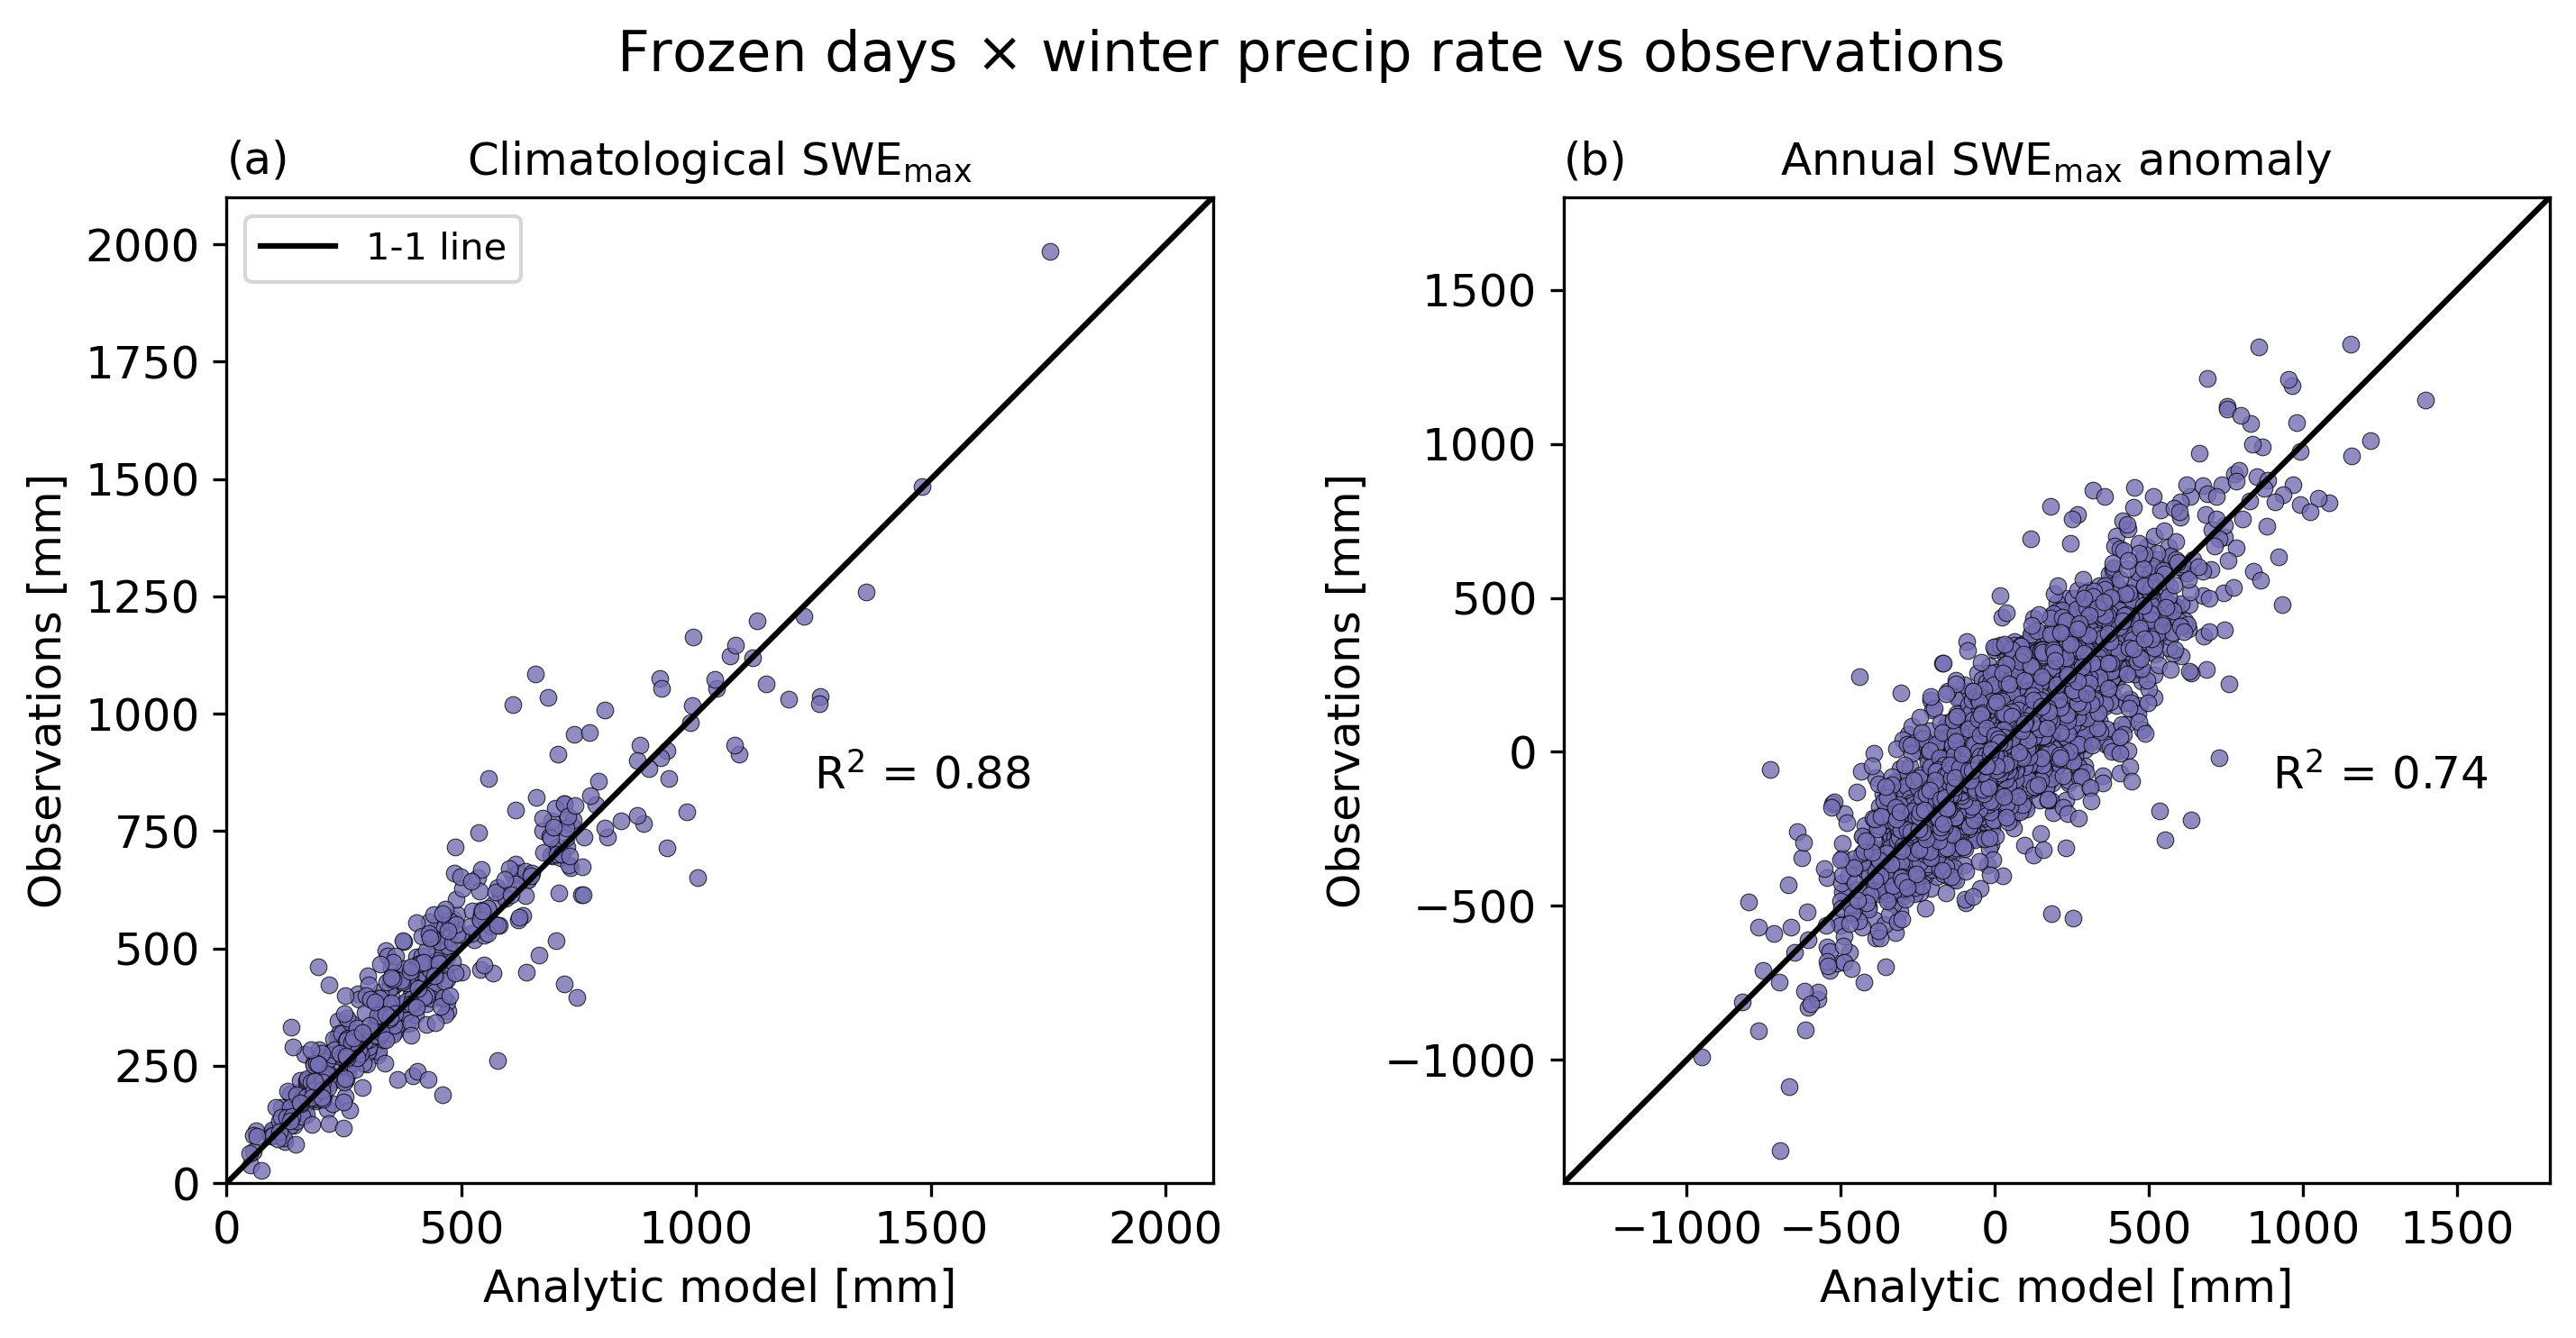

In [47]:
fig = plt.figure(figsize=(10,5),dpi=300)
gs = GridSpec(1,2)

figFontSize = 12

colorTimeDep = '#1b9e77'
colorAnalytic = '#7570b3'
#1b9e77
#d95f02
#7570b3

########################################################

#### Model vs obs climatological max SWE ####
ax0 = fig.add_subplot(gs[0])

xData2 = analyticStation
yData2 = obsStation
thisR2 = round(R2_from1to1(xData2,yData2),2)
ax0.scatter(xData2[0],yData2[0],20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax0.scatter(xData2,yData2,20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax0.text(1250,840,fr'R$^2$ = {thisR2}',fontsize=figFontSize)

ax0.set_ylabel('Observations [mm]',fontsize=figFontSize)
ax0.set_xlabel('Analytic model [mm]',fontsize=figFontSize)
ax0.axis('square')
ax0.set_xlim([0,2100])
ax0.set_ylim([0,2100])
ax0.set_title(r'Climatological SWE$_\text{max}$',fontsize=figFontSize)

## Plot 1-1 line ##
ax0.plot(np.arange(0,2100),np.arange(0,2100),c='k',label='1-1 line')

ax0.legend(fontsize=figFontSize-2,loc='upper left')

ax0.tick_params(axis='both', labelsize=figFontSize)

ax0.text(0,2150,'(a)',fontsize=figFontSize)

########################################################


#### Model vs obs deviation from climatological max SWE ####
ax1 = fig.add_subplot(gs[1])

xData2 = analyticWY
yData2 = obsWY
thisR2 = round(R2_from1to1(xData2,yData2),2)
ax1.scatter(xData2[0],yData2[0],20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax1.scatter(xData2,yData2,20,edgecolor='k',linewidth=.25,alpha=.8,c=colorAnalytic)
ax1.text(900,-120,fr'R$^2$ = {thisR2}',fontsize=figFontSize)

ax1.set_ylabel('Observations [mm]',fontsize=figFontSize)
ax1.set_xlabel(r'Analytic model [mm]',fontsize=figFontSize)
ax1.axis('square')
ax1.set_xlim([-1400,1800])
ax1.set_ylim([-1400,1800])
ax1.set_title(r'Annual SWE$_\text{max}$ anomaly',fontsize=figFontSize)

## Plot 1-1 line ##
ax1.plot(np.arange(-1400,1800),np.arange(-1400,1800),c='k',label='1-1 line')

#ax1.legend(fontsize=figFontSize-2,loc='upper left')

ax1.tick_params(axis='both', labelsize=figFontSize)
ax1.text(-1400,1875,'(b)',fontsize=figFontSize)

fig.suptitle(r'Frozen days $\times$ winter precip rate vs observations',fontsize=15)
fig.subplots_adjust(top=0.75)
plt.tight_layout()

## option to save figure ##
saveFigBool = False
if saveFigBool:
    plt.savefig('...../figure3_AnalyticOnly.pdf')

# Figure 4

PDF of nondimensionalized SWE data. Data computed in sweUniversal.ipynb.

/tmp/ipykernel_142120/1203384001.py:18: RuntimeWarning: divide by zero encountered in log
  c = ax0.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone_r',levels=np.arange(-10,-4))
/tmp/ipykernel_142120/1203384001.py:47: RuntimeWarning: divide by zero encountered in log
  c = ax1.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-3,3,1),cmap='bone_r')


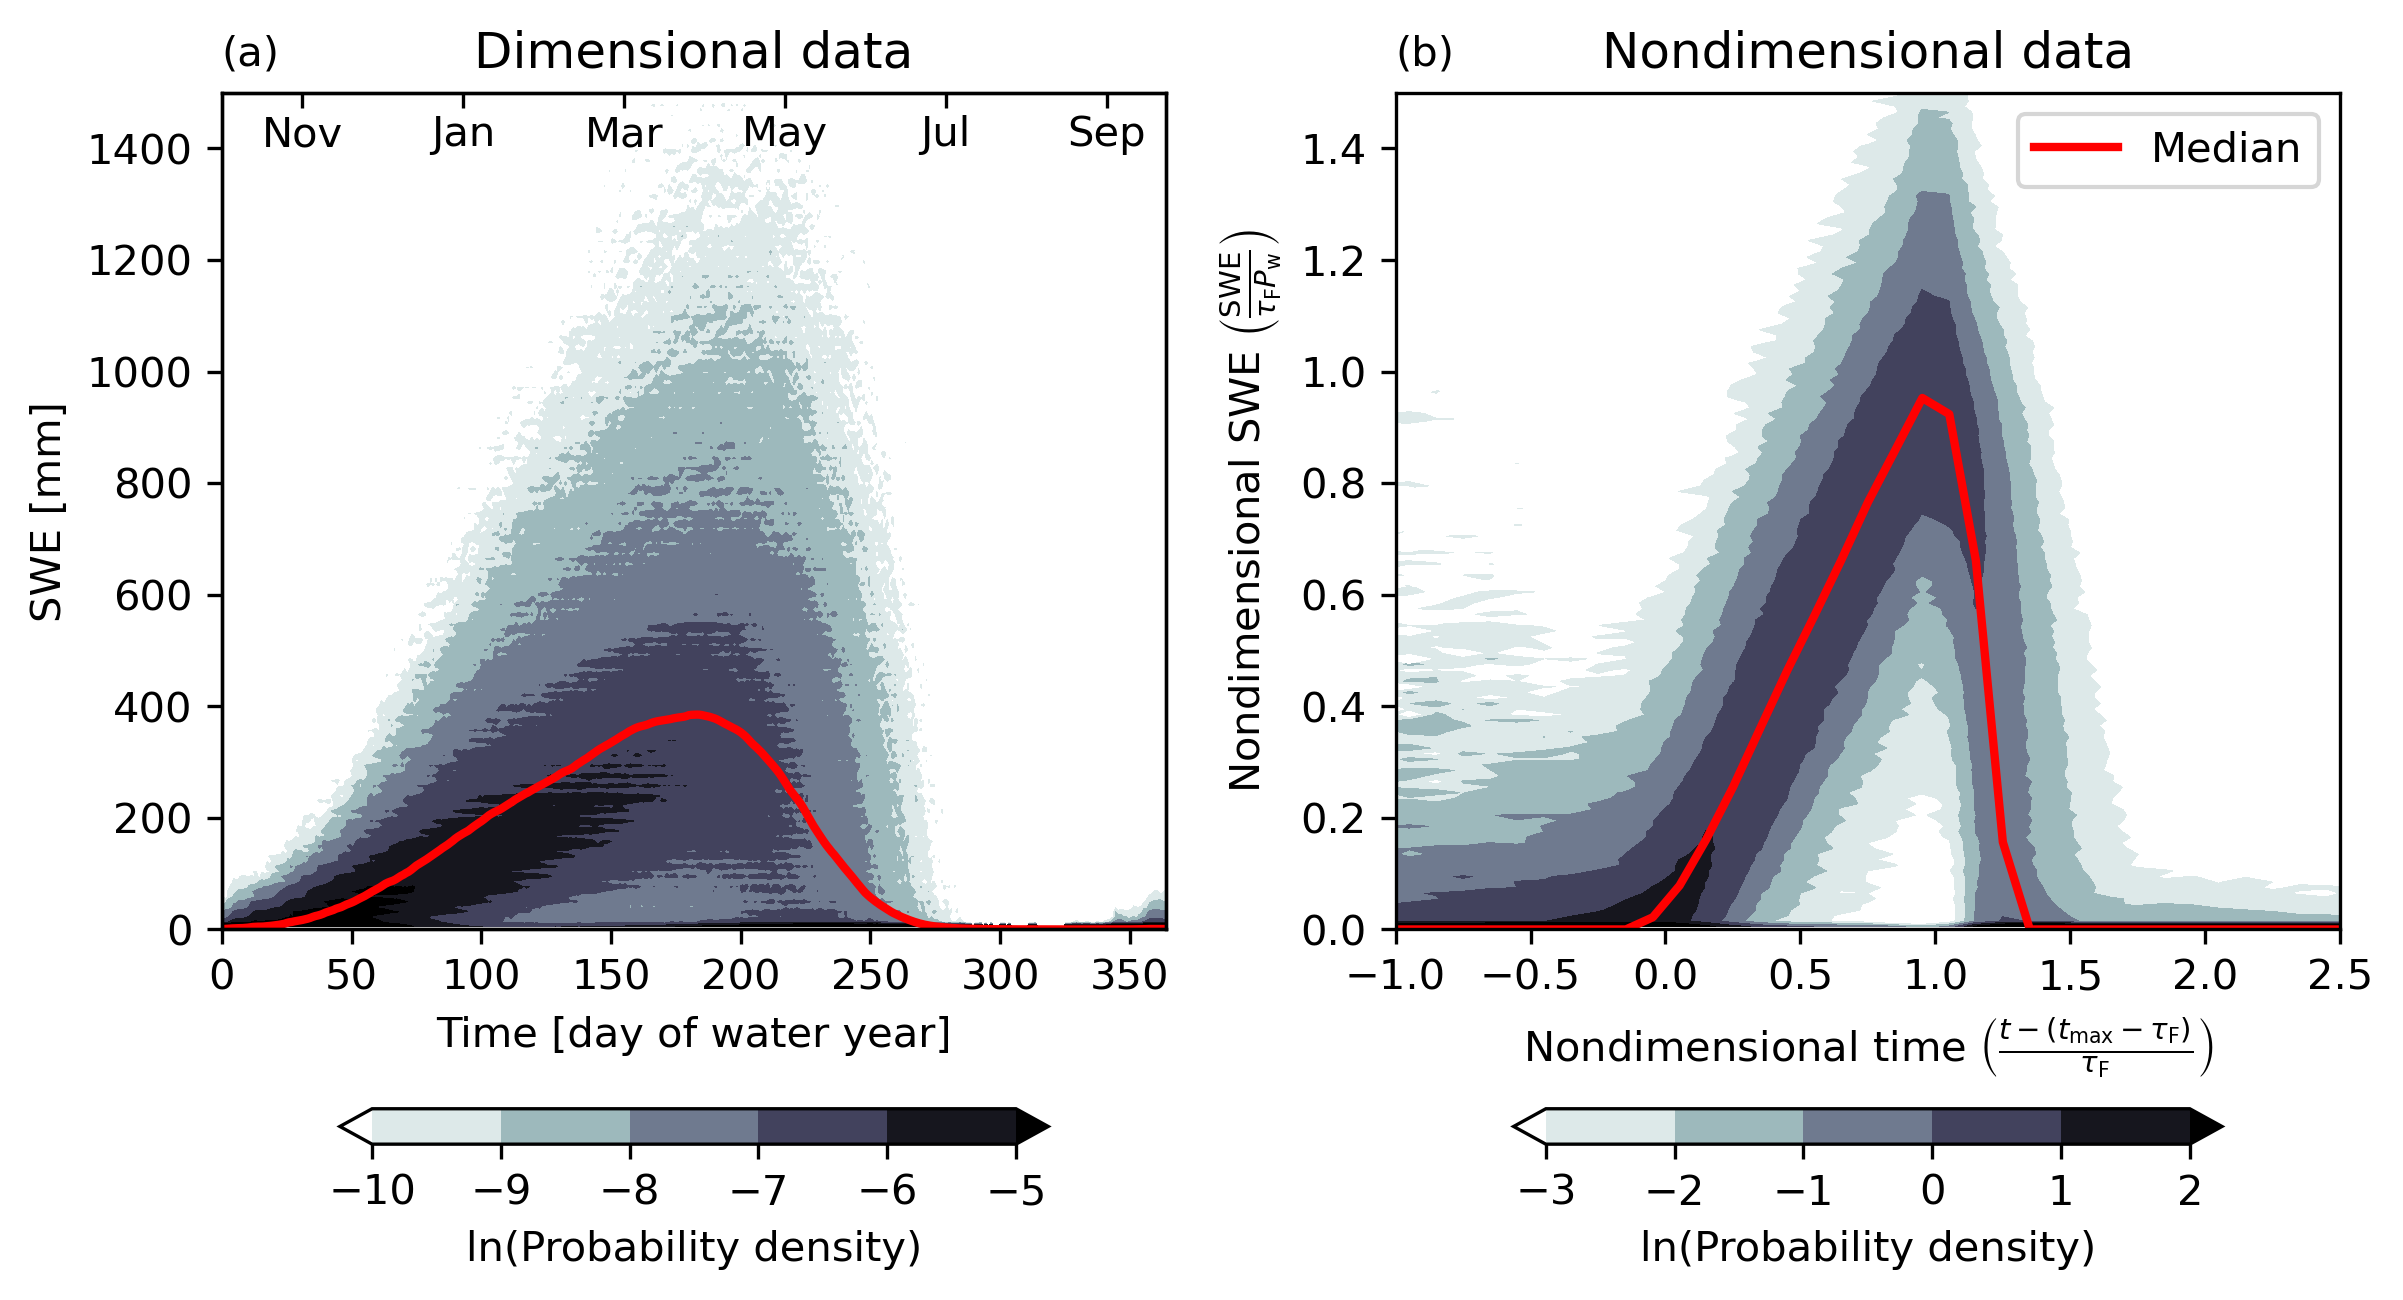

In [158]:
fig, ax = plt.subplots(1,2,figsize=(8,4.5),dpi=300)
ax0 = ax[0]
ax1 = ax[1]

###########################################
# Plot dimensional climatological data #
###########################################

### Load the dimensional SWE timeseries data ###
sweTimeSeriesData = np.load(pathToLoad + '/figure4SWECurvesDim_Water year.npz')
Xmean = sweTimeSeriesData['Xmean']
Ymean = sweTimeSeriesData['Ymean']
tt = sweTimeSeriesData['tt']
bb = sweTimeSeriesData['bb']
allHist = sweTimeSeriesData['allHist']


c = ax0.contourf(tt,bb,np.log(allHist.T),extend='both',cmap='bone_r',levels=np.arange(-10,-4))
plt.colorbar(c,ax=ax0,label='ln(Probability density)',orientation='horizontal',shrink=.75)
ax0.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax0.set_ylabel(r'SWE [mm]')
ax0.set_xlabel('Time [day of water year]')
ax0.set_ylim([0,1500])
ax0.set_xticks(np.arange(0,400,50))
ax0.set_xlim([0,364])

ax2 = ax0.twiny()
ax2.set_xlim([0,364])
ax2.set_xticks(np.arange(0,359,62)+31)
ax2.set_xticklabels(['Nov','Jan','Mar','May','Jul','Sep'],rotation=0);
ax2.tick_params(axis="x",direction="in",pad=-15)
ax0.set_title('Dimensional data')
ax0.text(0,1550,'(a)');

###########################################
# Plot nondimensional climatological data #
###########################################

### Load the nondimensional SWE timeseries data ###
sweTimeSeriesData = np.load(pathToLoad + '/figure4SWECurvesNonDim_Water year.npz')
Xmean = sweTimeSeriesData['Xmean']
Ymean = sweTimeSeriesData['Ymean']
tt = sweTimeSeriesData['tt']
bb = sweTimeSeriesData['bb']
allHist = sweTimeSeriesData['allHist']

c = ax1.contourf(tt,bb,np.log(allHist.T),extend='both',levels=np.arange(-3,3,1),cmap='bone_r')
plt.colorbar(c,ax=ax1,label='ln(Probability density)',orientation='horizontal',shrink=.75)
ax1.plot(Xmean,Ymean,linewidth=2,c='r',label='Median')
ax1.set_xlim([-1,2.5])
ax1.set_ylim([0,1.5])
ax1.legend()
ax1.set_ylabel(r'Nondimensional SWE $\left(\frac{\text{SWE}}{\tau_\text{F}P_\text{w}}\right)$')
ax1.set_xlabel(r'Nondimensional time $\left(\frac{t-(t_\text{max}-\tau_\text{F})}{\tau_\text{F}}\right)$')
ax1.set_title('Nondimensional data')
ax1.text(-1,1.55,'(b)');

plt.tight_layout()

## Save figure
saveBool = 0
if saveBool:
    plt.savefig(f'....../figure_universalSWECurve.pdf')

# Figure 5

Additive sensitivity of $\tau_\text{F}$, $P_\text{w}$, and $S_\text{max}$. Data is computed in Sensitivity.ipynb.

In [17]:
### Load sensitivity data ###
pathToLoad = '...../figureData'
sensitivityData = np.load(pathToLoad + '/figure5AddedSen.npz')

Tw_stationClim = sensitivityData['TwClim']
dlogPw_dTw = sensitivityData['dlogPw_dTw']
dlogTauF_dTw = sensitivityData['dlogTauF_dTw']
dlogSWE_dTw = sensitivityData['dlogSWE_dTw']

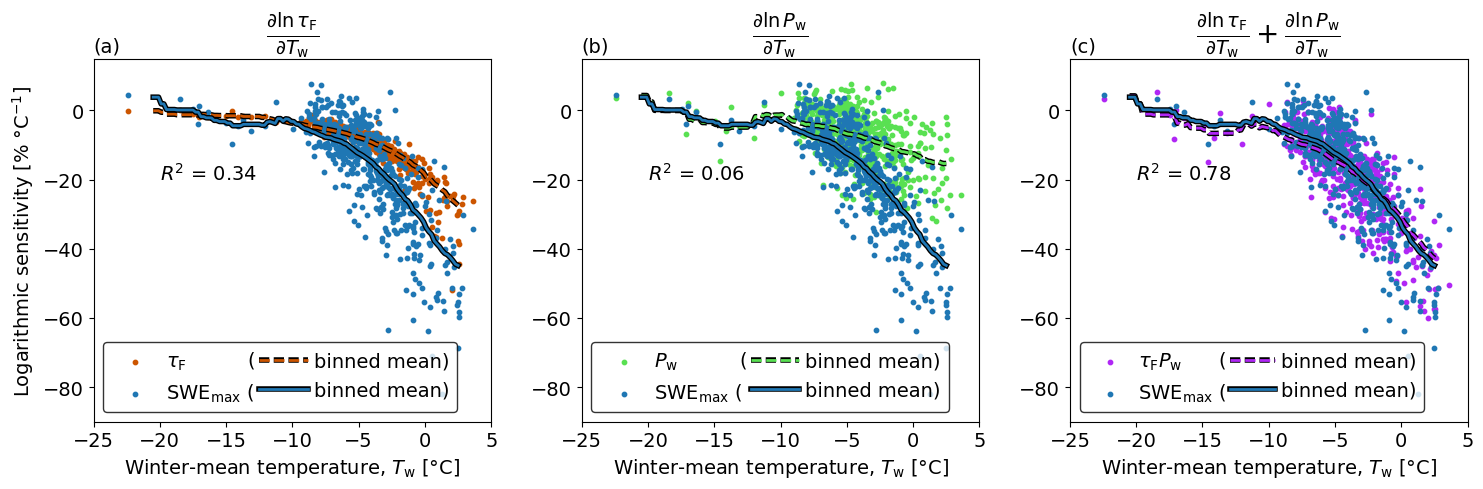

In [18]:
fig,axs = plt.subplots(1,3,figsize=(15,5))

xLabel = r'Winter-mean temperature, $T_\text{w}$ [$\degree$C]'

### Panel 1 ###
rowColor = '#CC5500'
ax1 = axs[0]
xData = Tw_stationClim
yData = dlogTauF_dTw
yData0 = dlogSWE_dTw
ax1.scatter(xData,yData,10,c=rowColor,label=r'$\tau_\text{F}$')
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax1.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'$\tau_\text{F}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax1.scatter(xData,yData0,10,label=r'$\text{SWE}_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax1.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$\text{SWE}_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax1.set_ylabel(r'Logarithmic sensitivity [% $\degree$C$^{-1}$]',rotation=90,labelpad=5,fontsize=14)
ax1.set_xlabel(xLabel,fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_ylim([-90,15])
ax1.set_xlim([-25,5])
ax1.set_title(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}$',fontsize=20)
ax1.text(-20,-20,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)
ax1.text(-25,17,'(a)',fontsize=14)

handles, labels = ax1.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax1.legend(handles_ordered, ('$\\tau_\\text{F}$          (', r'$\text{SWE}_\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)

### Panel 2 ###
rowColor = '#59E052'
ax2 = axs[1]
xData = Tw_stationClim
yData = dlogPw_dTw
yData0 = dlogSWE_dTw
ax2.scatter(xData,yData,10,label=r'$P_\text{w}$',c=rowColor)
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax2.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'$P_\text{w}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax2.scatter(xData,yData0,10,label=r'$\text{SWE}_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax2.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$\text{SWE}_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
#ax2.set_ylabel(r'$\frac{\partial \ln x}{\partial T_\text{w}}$ [% K$^{-1}$]',rotation=90,labelpad=5,fontsize=20)
ax2.set_xlabel(xLabel,fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_ylim([-90,15])
ax2.set_xlim([-25,5])
ax2.set_title(r'$\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$',fontsize=20)
ax2.text(-20,-20,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)
ax2.text(-25,17,'(b)',fontsize=14)

handles, labels = ax2.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax2.legend(handles_ordered, ('$P_\\text{w}$          (', r'$\text{SWE}_\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.5, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)


### Panel 3 ###
rowColor = '#B027F5'
ax3 = axs[2]
xData = Tw_stationClim
yData = (dlogPw_dTw+dlogTauF_dTw)
yData0 = dlogSWE_dTw
ax3.scatter(xData,yData,10,label=r'$\tau_\text{F} P_\text{w}$',c=rowColor)
binMidPt,binnedMean = binMeanFunction(yData,xData,5,.2)
ax3.plot(binMidPt,binnedMean,linewidth=2,color=rowColor,linestyle='--',label=r'binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
ax3.scatter(xData,yData0,10,label=r'$\text{SWE}_\text{max}$')
binMidPt,binnedMean = binMeanFunction(yData0,xData,5,.2)
ax3.plot(binMidPt,binnedMean,linewidth=2,linestyle='-',label=r'$\text{SWE}_\text{max}$ binned mean',path_effects=[pe.Stroke(linewidth=4, foreground='k'), pe.Normal()])
#ax3.set_ylabel(r'$\frac{\partial \ln x}{\partial T_\text{w}}$ [% K$^{-1}$]',rotation=90,labelpad=5,fontsize=20)
ax3.set_xlabel(xLabel,fontsize=14)
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_ylim([-90,15])
ax3.set_xlim([-25,5])
ax3.set_title(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}} + \frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$',fontsize=20)
ax3.text(-20,-20,fr'$R^2$ = {round(R2_from1to1(yData,yData0),2)}',fontsize=14)
ax3.text(-25,17,'(c)',fontsize=14)

handles, labels = ax3.get_legend_handles_labels()
handles_ordered_arr = np.array(handles).reshape(2, 2).T
handles_ordered = handles_ordered_arr.flatten()
ax3.legend(handles_ordered, (r'$\tau_\text{F}P_\text{w}$      (', r'$\text{SWE}_\text{max}$ (', 'binned mean)', 'binned mean)'),
          loc='lower left', ncol=2, handlelength=2.3, edgecolor='black',
           handletextpad=0.3, columnspacing=0.2,fontsize=14)

plt.tight_layout()

saveFigBool = 0
if saveFigBool:
    plt.savefig('...../figure5_analyticSenBreakdown.pdf')

# Figure 7

Behavior and sensitivity of $\tau_\text{F}$ with applied uniform warming. Data is computed in T0overT1.ipynb and sineWave.ipynb.

In [20]:
### Load \tau_F sensitvity data ###
pathToLoad = '...../figureData'
tauFSenData = np.load(pathToLoad + '/figure7Sen.npz')

TwArray = tauFSenData['TwArray']
Tw_adjs = tauFSenData['Tw_adjs']
odrBestFitFunction = np.poly1d(tauFSenData['odrBestFitFunction'])
adjTauFList = tauFSenData['adjTauFList']
tauFSenList_EtauF = tauFSenData['tauFSenList_EtauF']
stationApproxAmpsSin = tauFSenData['stationApproxAmpsSin']


### Load temperature data ###
    # from sineWave.ipynb
pathToLoad = '...../figureData'
tempData = np.load(pathToLoad + '/figure7Dist.npz')

winterInds = tempData['winterInds']
winterTemps = tempData['winterTemps']
compTemps = tempData['compTemps']
allTemps = tempData['allTemps']

groupedByDay = []
for i in range(365):
    specDayOfYear = []
    for j in range(36):
        specDayOfYear = specDayOfYear + [allTemps[i+j*365]]
    groupedByDay = groupedByDay + [specDayOfYear]

meanSeasonalCycle = np.array([np.nanmean(np.array(day)) for day in groupedByDay])
stdDevSeasonalCycle = np.array([np.nanstd(np.array(day)) for day in groupedByDay])

/tmp/ipykernel_918/3515475240.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  annualMeanTemp_i = Tw[i] - (1/(260-109))*np.trapz(T_prime)
/tmp/ipykernel_918/2696539499.py:107: RuntimeWarning: invalid value encountered in arccos
  tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,a)/a)
/tmp/ipykernel_918/2696539499.py:148: RuntimeWarning: invalid value encountered in arccos
  tauF_0sigma = 2/omega * np.arccos(T0overT1Range_fullDeterm)
/tmp/ipykernel_918/2696539499.py:149: RuntimeWarning: invalid value encountered in sqrt
  analyticDeriv_0sigma = -2/(omega*12)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma
/tmp/ipykernel_918/2696539499.py:149: RuntimeWarning: divide by zero encountered in divide
  analyticDeriv_0sigma = -2/(omega*12)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma
/tmp/ipykernel_918/3515475240.py:12: DeprecationWarning: `trapz` is deprecated. Use `trap

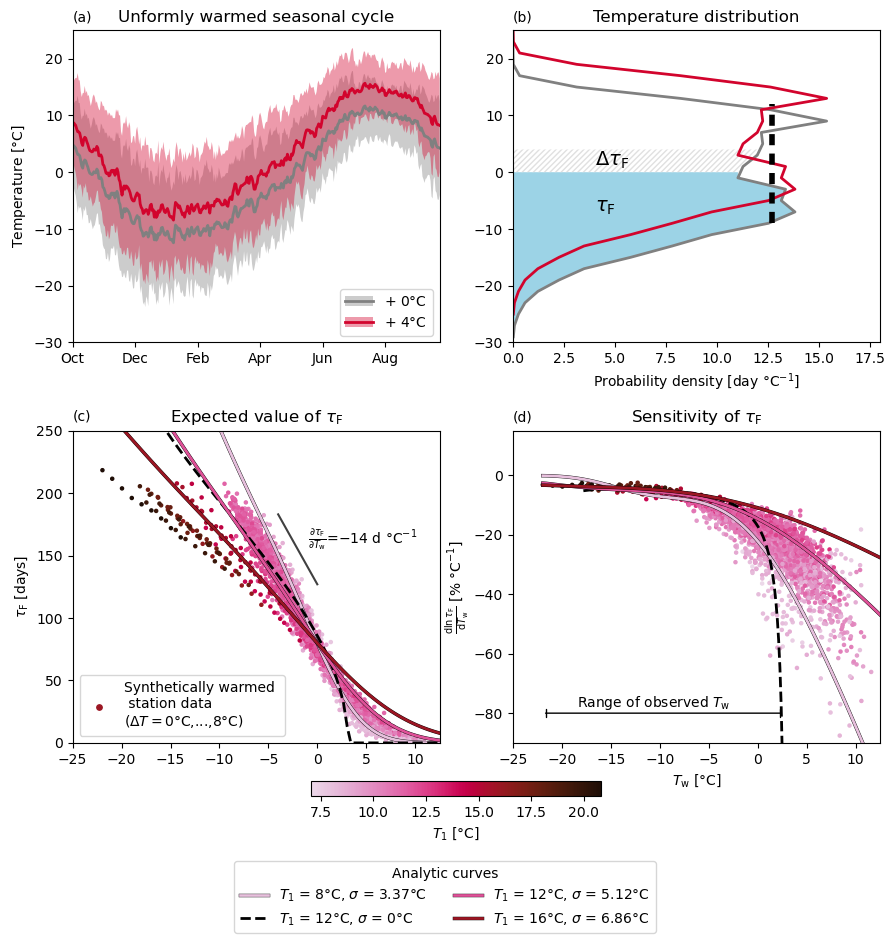

In [26]:
fig = plt.figure(figsize=(9,9))

gs = GridSpec(2,1)

topRow = gs[0].subgridspec(1,2,width_ratios=[1, 1])
bottomRow = gs[1].subgridspec(1,2)

                                    ########################
                                        ### Schematic ###
                                    ########################

#### Plot of seasonal cycle ####
ax0 = fig.add_subplot(topRow[0])

origSeasonalCycle = meanSeasonalCycle
origSTD = stdDevSeasonalCycle
origColor = '#808080'

ts = ax0.plot(origSeasonalCycle,linewidth=2,c=origColor)
ax0.fill_between(np.arange(365),origSeasonalCycle-2*origSTD,origSeasonalCycle+2*origSTD,alpha=.4,facecolor=origColor)
box = ax0.fill(np.nan, np.nan, alpha=0.4,facecolor=origColor) # for legend entry

warmingLevel = 4
warmColor = '#D2042D'
warmerSeasonalCycle = origSeasonalCycle + warmingLevel
tsW = ax0.plot(warmerSeasonalCycle,c=warmColor,linewidth=2)
ax0.fill_between(np.arange(365),warmerSeasonalCycle-2*origSTD,
                 warmerSeasonalCycle+2*origSTD,alpha=.4,facecolor=warmColor)
boxW = ax0.fill(np.nan, np.nan, warmColor, alpha=0.4) # for legend entry
ax0.legend([(box[0], ts[0]),(boxW[0], tsW[0])],
           [fr'+ {0}$\degree$C',fr'+ {warmingLevel}$\degree$C'])
ax0.set_ylim((-30,25))

ax0.set_ylabel(r'Temperature [$\degree$C]')

ax0.set_xlim([0,364])
ax0.set_xticks(np.arange(0,359,62))
ax0.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0)
ax0.text(0,26.5,'(a)')
title = ax0.set_title('Unformly warmed seasonal cycle')

#### Plot distributions ####
ax1 = fig.add_subplot(topRow[1])

bins = np.arange(-30,27,2)
pdf,binEdges = np.histogram(allTemps[~np.isnan(allTemps)], bins, density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2
ax1.plot(pdf*365,binCenters,linewidth=2,label=r'+ {0}$\degree$C',c=origColor)
zeroLine = np.zeros(binCenters.size)
ax1.fill_between(pdf*365,zeroLine,binCenters,alpha=.4,where=(zeroLine > binCenters),facecolor='#0992C2')

allTempsWarmer = allTemps + warmingLevel
ax1.plot(pdf*365,binCenters+4,linewidth=2,label=fr'+ {warmingLevel}$\degree$C',c=warmColor)

warmLine = np.ones(binCenters.size)*warmingLevel
domainMod = copy.deepcopy(binCenters)
domainMod[binCenters<0] = 0
ax1.fill_between(pdf*365,warmLine,domainMod,alpha=1,where=(warmLine > domainMod),
                 facecolor='none',linewidth=0,hatch='//////',edgecolor='#e0e0e0')

ax1.text(4,1.2,r'$\Delta\tau_\text{F}$',zorder=1,fontsize=14)

ax1.text(4,-7,r'$\tau_\text{F}$',zorder=1,fontsize=14)

flatStart = -9
flatEnd = 12
flDomain = np.arange(flatStart,flatEnd+1)
ax1.plot(np.ones(flDomain.shape)*np.mean(pdf[np.logical_and(binCenters>flatStart,binCenters<flatEnd)])*365,
         flDomain,
        c='k',linestyle=(0, (2, 1.5)),linewidth=4)
ax1.set_xlabel('Probability density [day $\degree$C$^{-1}$]')
ax1.set_title('Temperature distribution')
ax1.set_ylim((-30,25))
ax1.set_xlim((0,18))
ax1.text(0,26.5,'(b)')

# ax1.annotate(r'Area of blue shading = $\tau_\text{F}$', xy=(5, -5), xytext=(10, -20),
#             arrowprops=dict(facecolor='black', shrink=0.05),
#             )

################################################
        ### Numerical Experiments ###
################################################

### Colormap selection ###
normalize = Normalize(vmin=np.min(stationApproxAmpsSin), vmax=np.max(stationApproxAmpsSin))
scalarMap = ScalarMappable(norm=normalize, cmap=cmr.get_sub_cmap('cmr.flamingo_r', 0.1, 0.9))

####################################

#### Plot of tau_F ####
ax0 = fig.add_subplot(bottomRow[0])

### Add analytic curves ###
amplitudeRange = np.array([8,12,16])
TwRange = np.linspace(np.min(TwArray),15,100) 

# compute sigma based on best fit between sigma and T1 in obs
sigma_fromBestFit = odrBestFitFunction(amplitudeRange)

## add determinsitic curve ##
omega = 2*np.pi/365

## add noisy curves ##
for ja,a in enumerate(amplitudeRange):
    if ja==1: # plot deterministic curve now
        tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,a)/a)
        tauF_0sigma[np.logical_and(np.isnan(tauF_0sigma),TwRange>-10)]=0
        ax0.plot(TwRange,tauF_0sigma,linewidth=2,
                 linestyle='--',c='k')#,label=r'$T_1$ = 12$\degree$C, $\sigma$ = 0$\degree$C')
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle to map Tw to T0
    ax0.plot(TwRange,E_tauF_normalDistDaily(a,sigma_fromBestFit[ja],T0Range),linewidth=2,
             c=scalarMap.to_rgba(a),
            path_effects=[pe.Stroke(linewidth=2.5, foreground='k'), pe.Normal()])
            # label=r'$T_1$ = ' + f'{a}' + r'$\degree$C, $\sigma$ = '+f'{round(sigma_fromBestFit[ja],2)}' + r'$\degree$C'

## add station data ##
for l,adj in enumerate(Tw_adjs):
    ax0.scatter(TwArray[l],adjTauFList[l],5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

# for legend
ax0.scatter(TwArray[0]-100,adjTauFList[0],15,color=scalarMap.to_rgba(16),
            label='Synthetically warmed \n station data \n' + r'($\Delta T = 0\degree$C,...,8$\degree$C)')

## add demo slope to show linearity of tau_F##
demoRange = np.linspace(-2,2,30)
ax0.plot(demoRange-2,-14*(demoRange)+155,c='k',alpha=.75)
ax0.text(-1,160,r'$\frac{\partial\tau_\text{F}}{\partial T_\text{w}}$=$-$14 d $\degree$C$^{-1}$',fontsize=10)

ax0.set_ylim(0,250);
ax0.set_xlim([-25,12.5])
ax0.set_ylabel(r'$\tau_\text{F}$ [days]')

ax0.legend(loc='lower left')

ax0.set_title(r'Expected value of $\tau_\text{F}$')

ax0.text(-25,258,'(c)')

#### Plot of tau_F sensitivity ####
ax1 = fig.add_subplot(bottomRow[1])

### Add analytic curves ###

## add determinsitic curve ##
T0overT1Range_fullDeterm = np.linspace(-.75,2.5,300)
omega = 2*np.pi/365
tauF_0sigma = 2/omega * np.arccos(T0overT1Range_fullDeterm)
analyticDeriv_0sigma = -2/(omega*12)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma

## add noisy curves ##
for ja,a in enumerate(amplitudeRange):
    if ja==1: # plot deterministic curve now
        ax1.plot(Tw_fromCos(T0overT1Range_fullDeterm*a,a),analyticDeriv_0sigma*100,linewidth=2,linestyle='--',
        c='k',label=r'$T_1$ = 12$\degree$C, $\sigma$ = 0$\degree$C')
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle
    analyticDeriv = (np.gradient(np.log(E_tauF_normalDistDaily(a,sigma_fromBestFit[ja],T0Range)))/(np.gradient(TwRange)))
    ax1.plot(TwRange,analyticDeriv*100,linewidth=2,
             label=r'$T_1$ = ' + f'{a}' + r'$\degree$C, $\sigma$ = '+f'{round(sigma_fromBestFit[ja],2)}' + r'$\degree$C',
             c=scalarMap.to_rgba(a),
            path_effects=[pe.Stroke(linewidth=2.5, foreground='k'), pe.Normal()])

## add station data ##
for l,adj in enumerate(Tw_adjs):
    colorbarPlot = ax1.scatter(TwArray[l],tauFSenList_EtauF[l]*100,5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

cbar = fig.colorbar(colorbarPlot,ax=[ax0,ax1],shrink = .6,orientation='horizontal',fraction=0.046, pad=0.04)
cbar.ax.set_xlabel(r'$T_1$ [$\degree$C]')

ax1.set_ylim([-90,15])
ax1.set_xlim([-25,12.5])

ax1.set_ylabel(r'$\frac{\text{d}\ln \tau_\text{F}}{\text{d}T_\text{w}}$' + ' [% $\degree$C$^{-1}$]',rotation=90,labelpad=2)
ax1.set_xlabel(r'$T_\text{w}$ [$\degree$C]')

### one legend for both plots ###
lines_labels = [ax1.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]

ax1.legend(lines, labels, loc = 'lower center', bbox_to_anchor = (0, -0.05, 1, 1),
           bbox_transform = plt.gcf().transFigure,ncol=2,title='Analytic curves')

## add arrow showing modern station data ##
q_end, q_start = np.percentile(TwArray[0], [100 ,0])
ax1.annotate("", xytext=(q_start, -80), xy=(q_end-1, -80),
                arrowprops=dict(arrowstyle="|-|",edgecolor='k',linewidth=1,mutation_scale=3))
ax1.text(-18.5,-78,r'Range of observed $T_\text{w}$',fontsize=10)

ax1.set_title(r'Sensitivity of $\tau_\text{F}$')
ax1.text(-25,18,'(d)')

plt.tight_layout()

saveFigBool = 1
if saveFigBool:
    plt.savefig('..../figure7_tauFChanges4Panel.pdf',bbox_inches='tight')

# Supplement Figure: $k(t)$

Show the time series of $k(t)$, the degree-day factor. Values are computed in deduceKEmpirically.ipynb

In [27]:
### Load data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
kData = np.load(pathToLoad + '/figureSupp_k.npz',allow_pickle=True)

datesForPlot = kData['datesForPlot']
binCenters = kData['binCenters']
hist2d = kData['hist2d']

## Also load the median k(t) ##
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
kMedian = np.load(pathToLoad + '/figureSupp_kMedian.npy')

## Load the station count data ##
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
kCount = np.load(pathToLoad + '/figureSupp_kCount.npz')
numberOfMeltyStations = kCount['numberOfMeltyStations']

In [28]:
## Smooth kMedian ##
kMedianSmooth = movingAverage(np.append(np.append(kMedian,kMedian),kMedian),30)[366:366+366]

/tmp/ipykernel_918/2319712464.py:11: RuntimeWarning: divide by zero encountered in log
  ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
/tmp/ipykernel_918/2319712464.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
/tmp/ipykernel_918/2319712464.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)


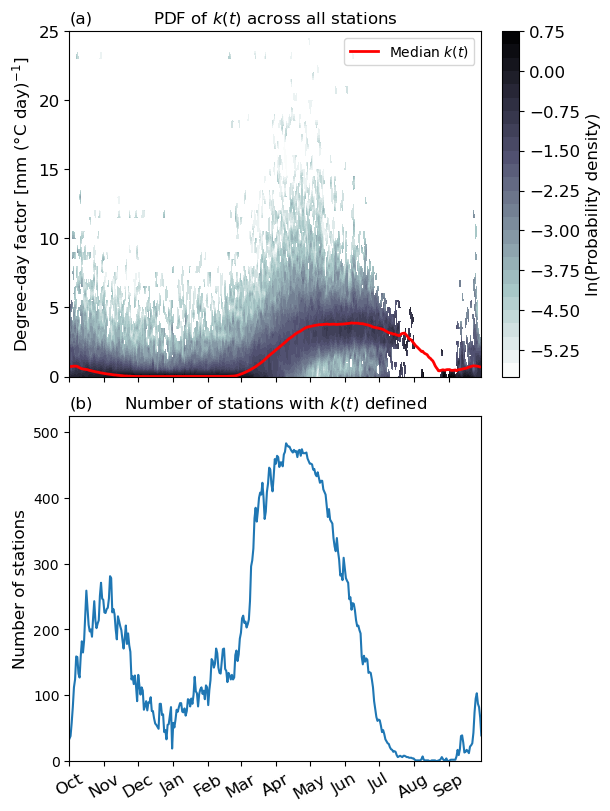

In [29]:
datedate,binbin = np.meshgrid(datesForPlot,binCenters)

### Set up figure ###
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True, layout='constrained')
figFontSize = 12
ax0=axs[0]
ax1=axs[1]

## Plot histogram of k across all stations ##
cmap = 'bone_r'#cmr.get_sub_cmap('cmr.neutral', 0.05, 0.95)
ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
ax0.tick_params(axis='x', labelrotation=0)
ax0.tick_params(axis='both', labelsize=figFontSize)
cbar = plt.colorbar(ctf)
cbar.ax.tick_params(labelsize=figFontSize)
cbar.set_label(label='ln(Probability density)',fontsize=figFontSize)
ax0.set_ylabel(r'Degree-day factor [mm $(\degree \text{C day})^{-1}$]',fontsize=figFontSize)
ax0.set_ylim([0,25])

ax0.plot(datesForPlot,kMedianSmooth,linewidth=2,c='r',label=r'Median $k(t)$')
ax0.set_title('PDF of $k(t)$ across all stations',fontsize=figFontSize)
ax0.text(datetime.datetime(1999, 10, 1, 0, 0),25.6,'(a)',fontsize=figFontSize)
ax0.legend()

## Plot count of stations contributing to median on each date ##
ax1 = plt.subplot(2,1,2)
ax1.plot(datesForPlot,numberOfMeltyStations)
ax1.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=90,fontsize=figFontSize)
ax1.tick_params(axis='x', labelrotation=30)
ax1.set_xlim([min(datesForPlot),max(datesForPlot)])
#ax1.set_ylim([0,850])
ax1.set_ylabel(r'Number of stations',fontsize=figFontSize)
ax1.set_title(fr'Number of stations with $k(t)$ defined',fontsize=figFontSize)
ax1.set_ylim([0,525])
ax1.text(datetime.datetime(1999, 10, 1, 0, 0),537,'(b)',fontsize=figFontSize)

saveFigBool = True
if saveFigBool:
    plt.savefig('/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_k.pdf',bbox_inches='tight')

## Version for talk

/tmp/ipykernel_3616/468610750.py:10: RuntimeWarning: divide by zero encountered in log
  ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
/tmp/ipykernel_3616/468610750.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=45,fontsize=figFontSize)


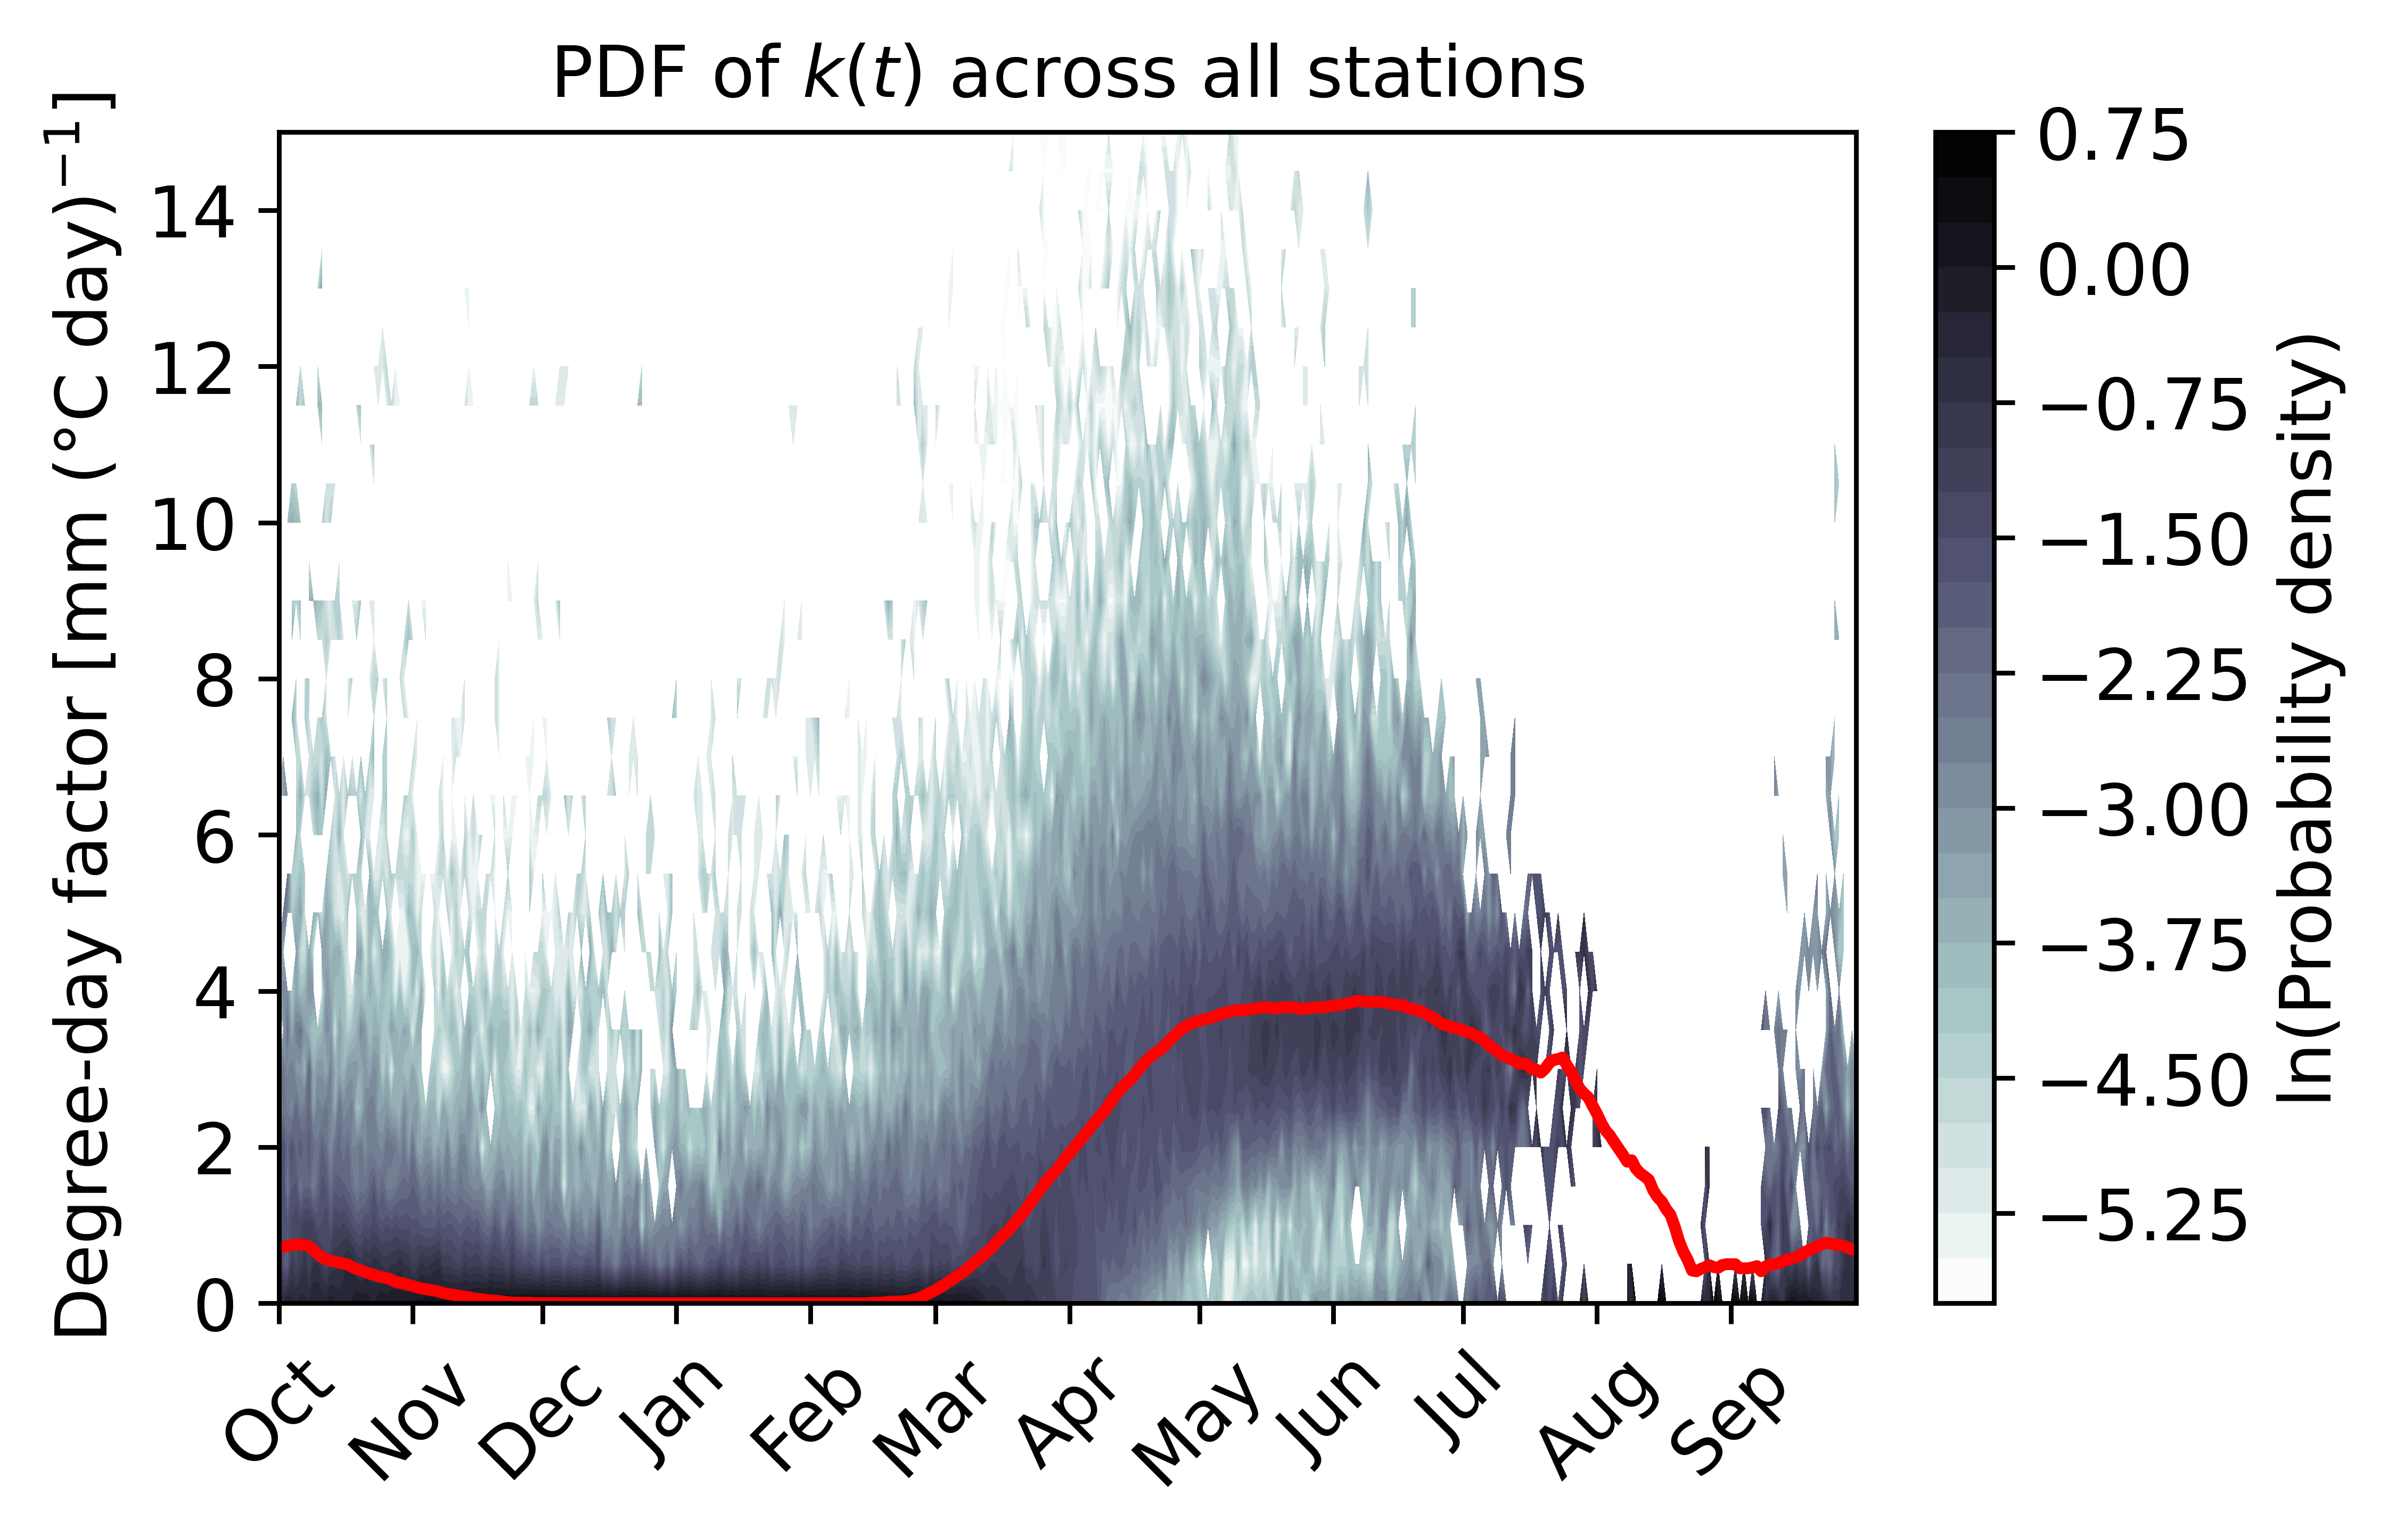

In [20]:
datedate,binbin = np.meshgrid(datesForPlot,binCenters)

### Set up figure ###
fig, axs = plt.subplots(1, 1, figsize=(5.5, 3.5), layout='constrained',dpi=800)
figFontSize = 12
ax0=axs

## Plot histogram of k across all stations ##
cmap = 'bone_r'#cmr.get_sub_cmap('cmr.neutral', 0.05, 0.95)
ctf = ax0.contourf(datedate,binbin,np.log(hist2d),levels=30,cmap=cmap)
ax0.set_xticklabels(['Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep'],rotation=45,fontsize=figFontSize)
ax0.tick_params(axis='x', labelrotation=45)
ax0.tick_params(axis='both', labelsize=figFontSize)
cbar = plt.colorbar(ctf)
cbar.ax.tick_params(labelsize=figFontSize)
cbar.set_label(label='ln(Probability density)',fontsize=figFontSize)
ax0.set_ylabel(r'Degree-day factor [mm $(\degree \text{C day})^{-1}$]',fontsize=figFontSize)
ax0.set_ylim([0,15])

ax0.plot(datesForPlot,kMedianSmooth,linewidth=2,c='r',label=r'Median $k(t)$')
ax0.set_title('PDF of $k(t)$ across all stations',fontsize=figFontSize)
#ax0.legend()

saveFigBool = True
if saveFigBool:
    plt.savefig('/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_k_talk.png',bbox_inches='tight')

# Supplement Figure: $P_\text{w}$ vs $P_{\tau_\text{F}}$

Plot the precipitation rate averaged during the winter ($P_\text{w}$) against that averaged on days with $T<0$  ($P_{\tau_\text{F}}$). Calculated in modelHeirarchy.ipynb.

In [30]:
### Load data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
pData = np.load(pathToLoad + '/figureSupp_PwPtauF.npz',allow_pickle=True)

pTauFAll = pData['pTauFAll']
pwAll = pData['pwAll']
pTauFMean = pData['pTauFMean']
pwMean = pData['pwMean']

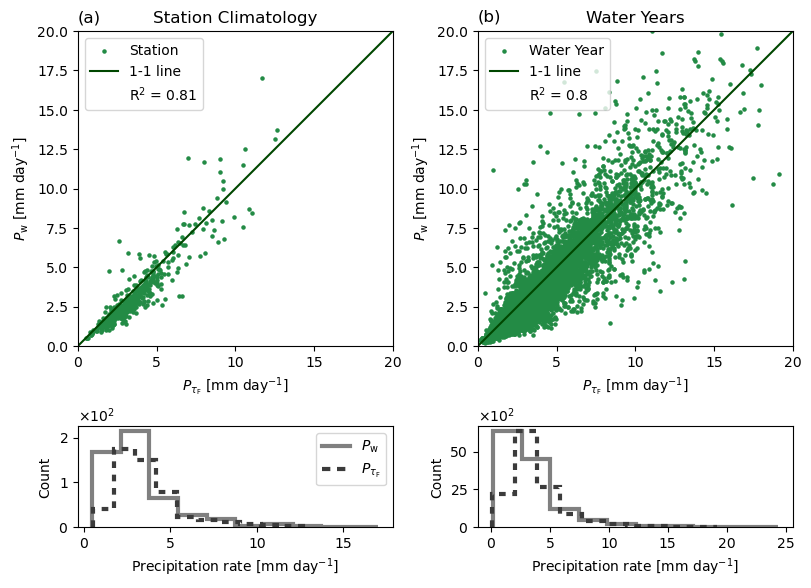

In [31]:
### Plot ###
supTitleFontSize = 16
titleFontSize = 12
fig, axs = plt.subplot_mosaic([['scatMean', 'scatAll'],
                               ['histMean', 'histAll']],
                              figsize=(8, 6),
                              width_ratios=(1, 1), height_ratios=(4, 1),
                              layout='constrained')


#### Mean across years ####
ax0 = axs['scatMean']
ax0.scatter(pTauFMean,pwMean,5,label='Station',c = '#238b45')#8A9A5B  ba3c3c
ax0.set_ylabel(r'$P_\text{w}$ [mm day$^{-1}$]')
ax0.set_xlabel(r'$P_{\tau_\text{F}}$ [mm day$^{-1}$]')
ax0.axis('square')
ax0.set_xlim([0,20])
ax0.set_ylim([0,20])

## Plot 1-1 line ##
ax0.plot(np.arange(-50,50),np.arange(-50,50),c='#004700',label='1-1 line')
thisR2 = R2_from1to1(pTauFMean,pwMean)
ax0.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,2)}')

ax0.legend()
ax0.set_title('Station Climatology',fontsize=titleFontSize)
ax0.text(0,20.6,'(a)',fontsize=titleFontSize)

## least squares best fit line (not shown) ##
# slope,R2 = leastSquaresSlope(xData0,yData0)
# ax0.plot(xData,xData*slope,c='#114060',label='Least squares best fit')
# ax0.plot([], [], ' ', label=fr'$\beta$ = {round(slope,3)}')
# ax0.plot([], [], ' ', label=fr'R$^2$ = {round(R2,3)}')
# ax0.legend()

#### Histogram for the climatology ####
ax01 = axs['histMean']
ax01.hist(pwMean,histtype='step',linewidth=3,label=r'$P_\text{w}$',color='#808080')
ax01.hist(pTauFMean,histtype='step',linewidth=3,label=r'$P_{\tau_\text{F}}$',linestyle=(0, (1.6, 1.6)),color='#3B3B3B')
ax01.ticklabel_format(axis='y',scilimits=(2,2),useMathText=True)
ax01.set_ylabel('Count')
ax01.set_xlabel('Precipitation rate [mm day$^{-1}$]')
handles, labels = ax01.get_legend_handles_labels()
leg_entries = {}
for h, label in zip(handles, labels):
    if label==r'$P_{\tau_\text{F}}$':
        linestyle = (0, (2, 1.6))
    else:
        linestyle = 'solid'
    leg_entries[label] = Line2D([0], [0], color=h.get_facecolor()[:-1],
                                alpha=h.get_alpha(), lw=h.get_linewidth(), linestyle = linestyle)
labels_sorted, lines = zip(*sorted(leg_entries.items()))
ax01.legend(lines, labels_sorted)

#### Showing all years ####
ax1 = axs['scatAll']
ax1.scatter(pTauFAll,pwAll,5,c='#238b45',label='Water Year')
ax1.set_ylabel(r'$P_\text{w}$ [mm day$^{-1}$]')
ax1.set_xlabel(r'$P_{\tau_\text{F}}$ [mm day$^{-1}$]')
ax1.axis('square')
ax1.set_xlim([0,20])
ax1.set_ylim([0,20])

## Plot 1-1 line ##
ax1.plot(np.arange(-1100,1800),np.arange(-1100,1800),c='#004700',label='1-1 line')
thisR2 = R2_from1to1(pTauFAll,pwAll)
ax1.plot([], [], ' ', label=fr'R$^2$ = {round(thisR2,2)}')

ax1.legend(loc='upper left')
ax1.set_title('Water Years',fontsize=titleFontSize)
ax1.text(0,20.6,'(b)',fontsize=titleFontSize)

#### Histogram for individual years ####
ax11 = axs['histAll']
ax11.hist(pwAll,histtype='step',linewidth=3,color='#808080')
ax11.hist(pTauFAll,histtype='step',linewidth=3,color='#3B3B3B',linestyle=(0, (1.6, 1.6)))
ax11.ticklabel_format(axis='y',scilimits=(2,2),useMathText=True)
ax11.set_ylabel('Count')
ax11.set_xlabel('Precipitation rate [mm day$^{-1}$]')


#fig.suptitle(r'$P_\text{w}$ vs $P_{\tau_\text{F}}$',fontsize=supTitleFontSize)
#plt.tight_layout()


saveFigBool = True
if saveFigBool:
    plt.savefig('/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_PwPtauF.pdf',bbox_inches='tight')

# Supplement Figure: Correlation between $\tau_\text{F}$ and $P_\text{w}$

Data calculated in tauf_pPbar_variability.ipynb.

In [3]:
### Load data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
tauFPwCorrData = np.load(pathToLoad + '/figureSupp_tauFPCorr.npz')

lons = tauFPwCorrData['lons']
lats = tauFPwCorrData['lats']
pearsonRs = tauFPwCorrData['pearsonRs']

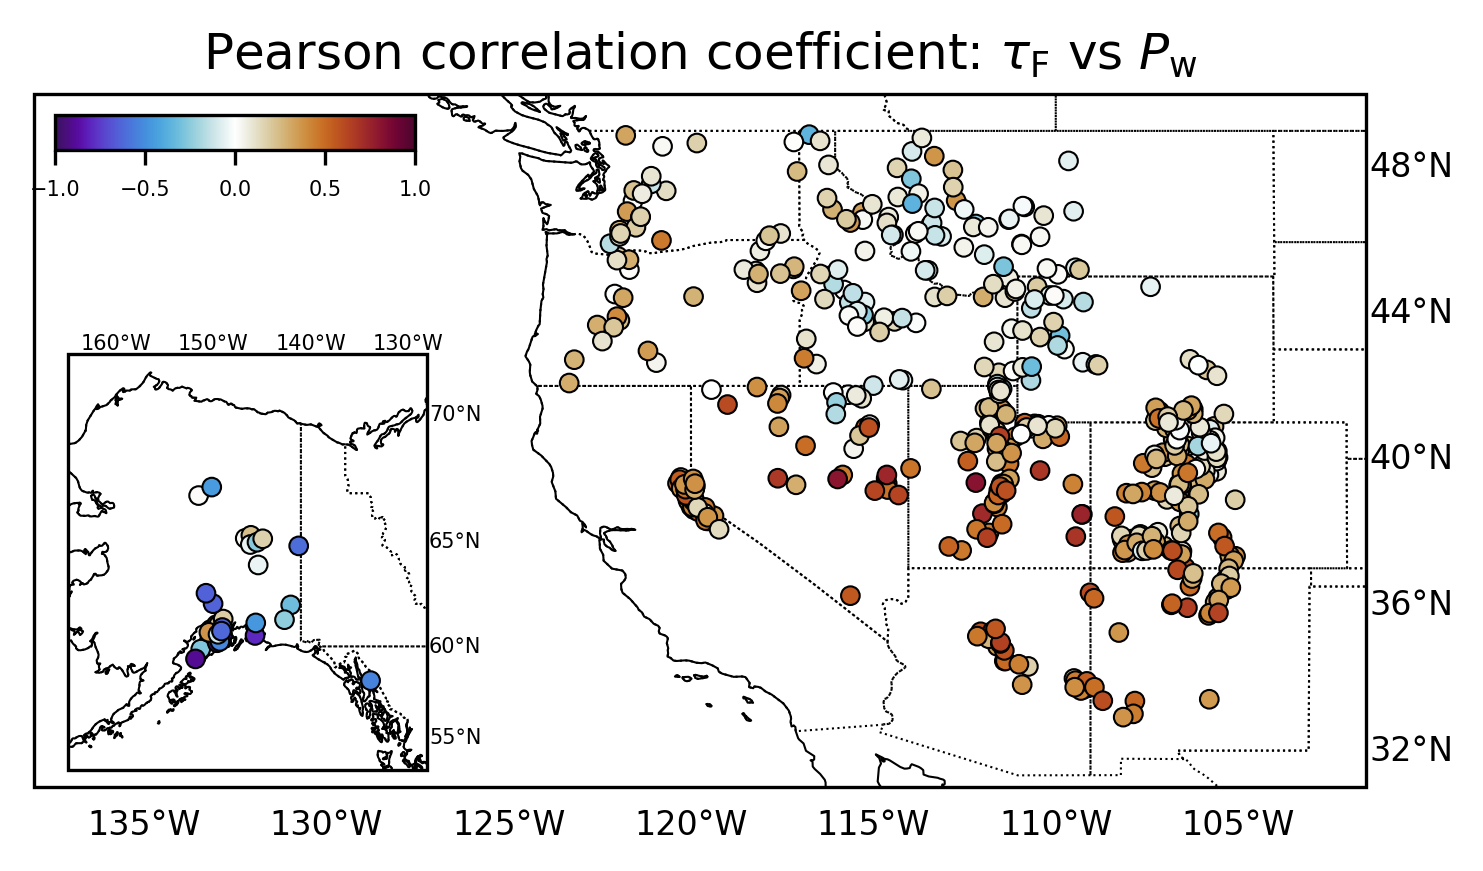

In [4]:
fig = plt.figure(figsize=(8,3),dpi=300)
gs = GridSpec(1, 1)

#############################################
## \tau_F vs P_w plot ##

# Continental US Stations #
ax0 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())

# Add coastlines
ax0.coastlines(linewidth=0.5,zorder=-1)

# Add U.S. state borders
ax0.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
gl.xlabel_style = {'size': 8, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 8, 'color': 'k', 'ha':'right'}

cmap = cmr.get_sub_cmap('cmr.fusion_r', 0.05, 0.95)

scatterSize = 20

sc = ax0.scatter(lons,lats,scatterSize,
                 c=pearsonRs,cmap=cmap,edgecolor='k',linewidth=.5,zorder=0,clim=[-1,1])

# Alaska stations #
axins = ax0.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
axins.scatter(lons,lats,scatterSize,
              c=pearsonRs,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0)
axins.coastlines(linewidth=0.5,zorder=-1)
axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
lon1, lon2, lat1, lat2 = -165, -128, 53, 72
axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.bottom_labels = False
gl.left_labels = False
gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
gl.xlabel_style = {'size': 5, 'color': 'k', 'va':'top'}
gl.ylabel_style = {'size': 5, 'color': 'k', 'ha':'right'}


# add colorbar
cbaxes = inset_axes(ax0,
    width="27%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",
)
cbaxes.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(sc,cax=cbaxes,#label='Climatological Peak SWE (mm)'
            orientation='horizontal')
cbar.ax.tick_params(labelsize=5)

ax0.set_title(r'Pearson correlation coefficient: $\tau_\text{F}$ vs $P_\text{w}$')

lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
ax0.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

saveFigBool = False
if saveFigBool:
    plt.savefig(f'/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/forScience/figureSupp_corrTauFPw.pdf')

In [17]:
np.mean(pearsonRs[np.logical_and(lats>42,lats<55)])

np.float64(0.06371675601437159)

# Supplement Figure: $\sigma$, $T_1$

Showing $\sigma$ and $T_1$, along with best fit line. 
Values are computed in T0overT1.ipynb

In [50]:
### Load data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
sigmaT1Data = np.load(pathToLoad + '/figureSupp_sigmaT1.npz')

stationApproxAmpsSin = sigmaT1Data['stationApproxAmpsSin']
stationWinterDailySTD = sigmaT1Data['stationWinterDailySTD']

## Also get Tw from figure 3 data ##
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
sensitivityData = np.load(pathToLoad + '/figure3AddedSen.npz')

Tw_stationClim = sensitivityData['TwClim']

In [51]:
## Plotting function adopted from the matplotlib documentation ##
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    for_cBar = ax.scatter(x, y,c=Tw_stationClim,cmap='Oranges')


    binsY = np.linspace(min(y),max(y),12)
    binsX = np.linspace(min(x),max(x),12)
    ax_histx.hist(x, bins=binsX,facecolor='#899499')
    ax_histx.set_ylabel('Count')
    ax_histy.hist(y, bins=binsY, orientation='horizontal',facecolor='#899499')
    ax_histy.set_xlabel('Count')

    return for_cBar

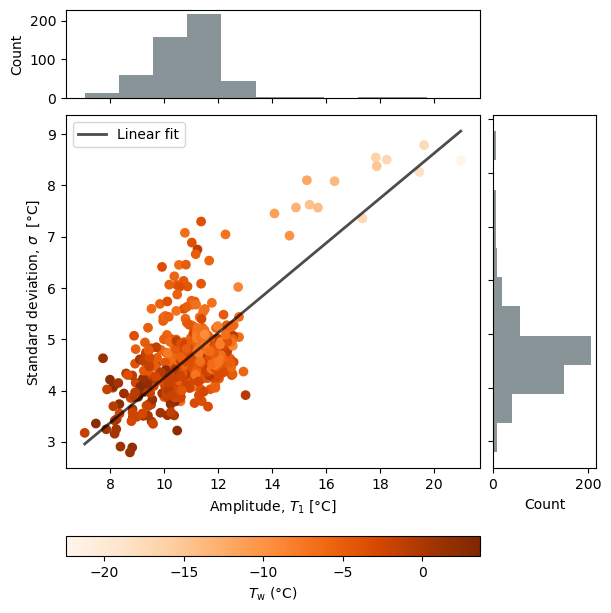

In [54]:
fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              figsize=(6, 6),
                              width_ratios=(4, 1), height_ratios=(1, 4),
                              layout='constrained')
for_cBar = scatter_hist(stationApproxAmpsSin, stationWinterDailySTD, axs['scatter'], axs['histx'], axs['histy'])

cbar = fig.colorbar(for_cBar,location='bottom')
cbar.ax.set_xlabel(r'$T_\text{w}$ ($\degree$C)')

### Plot best fit curves ###
def f(B, x):
    '''Linear function y = m*x + b'''
    return B[0]*x + B[1]
linear = odr.Model(f)
mydata = odr.Data(stationApproxAmpsSin,stationWinterDailySTD)
myodr = odr.ODR(mydata, linear, beta0=[1., 2.])
odrParams = myodr.run()
bestFitDomain = np.linspace(min(stationApproxAmpsSin),max(stationApproxAmpsSin),100)
## Plot the ODR best fit ##
odrBestFitFunction = np.poly1d(odrParams.beta)
axs['scatter'].plot(bestFitDomain,odrBestFitFunction(bestFitDomain),label='Linear fit',linewidth=2,c='k',alpha = .7)
axs['scatter'].legend()

axs['scatter'].set_ylabel(r'Standard deviation, $\sigma$  [$\degree$C]')
axs['scatter'].set_xlabel(r'Amplitude, $T_1$ [$\degree$C]')


saveFigBool = True
if saveFigBool:
    plt.savefig('/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_sigmaT1.pdf',bbox_inches='tight')

# Supplement Figure: Sensitivity maps and correlations

Map of sensitivity of $\tau_\text{F}$, $P_\text{w}$, and $S_\text{max}$. Data is computed in Sensitivity.ipynb.

In [55]:
### Load sensitivity data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
sensitivityData = np.load(pathToLoad + '/figure3AddedSen.npz')

Tw_stationClim = sensitivityData['TwClim']
dlogPw_dTw = sensitivityData['dlogPw_dTw']
dlogTauF_dTw = sensitivityData['dlogTauF_dTw']
dlogSWE_dTw = sensitivityData['dlogSWE_dTw']

### Load lat and lons ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
tauFPwCorrData = np.load(pathToLoad + '/figureSupp_tauFPCorr.npz')

lons = tauFPwCorrData['lons']
lats = tauFPwCorrData['lats']

In [57]:
def mapPlotFunction(ax,data,cmap,bounds,plotTitle):
    '''
    ax should result from the call of ax0 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
    data is used to color the station scatter points
    bounds is an np array that specifies the colorbar levels
    plotTitle is a string
    '''
    
    # Add coastlines
    ax.coastlines(linewidth=0.5,zorder=-1)
    
    # Add U.S. state borders
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.xlines = False
    gl.ylines = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.top_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator(np.arange(32,54,4))
    gl.xlabel_style = {'size': 7, 'color': 'k', 'va':'top'}
    gl.ylabel_style = {'size': 7, 'color': 'k', 'ha':'right'}
    
    scatterSize = 20
    
    # define the bins and normalize
    norm = matplotlib.colors.BoundaryNorm(bounds, getattr(plt.cm,cmap).N)
    
    sc = ax.scatter(lons,lats,scatterSize,
                     c=data,cmap=cmap,edgecolor='k',linewidth=.5,zorder=0,norm=norm)
    
    # Alaska stations #
    axins = ax.inset_axes(bounds = [-.14,0.025,0.6,.6],projection=ccrs.Mercator())
    axins.scatter(lons,lats,scatterSize,
                  c=data,cmap=cmap,edgecolor='k',linewidth=.5,transform=ccrs.PlateCarree(),zorder=0)
    axins.coastlines(linewidth=0.5,zorder=-1)
    axins.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5,zorder=-1)
    lon1, lon2, lat1, lat2 = -165, -128, 53, 72
    axins.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    gl = axins.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    gl.xlines = False
    gl.ylines = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.bottom_labels = False
    gl.left_labels = False
    gl.ylocator = mticker.FixedLocator(np.arange(55,75,5))
    gl.xlabel_style = {'size': 5, 'color': 'k', 'va':'top'}
    gl.ylabel_style = {'size': 5, 'color': 'k', 'ha':'right'}
    
    
    # add colorbar
    cbaxes = inset_axes(ax,
        width="27%",  # width: 50% of parent_bbox width
        height="5%",  # height: 5%
        loc="upper left",
    )
    cbaxes.xaxis.set_ticks_position("bottom")
    cbar = fig.colorbar(sc,cax=cbaxes,label=r'(% $\degree$C$^{-1}$)',
                orientation='horizontal')
    cbar.ax.tick_params(labelsize=5)
    
    ax.set_title(plotTitle,fontsize=20)
    
    lon1, lon2, lat1, lat2 = -138, -101.5, 31, 50
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

/tmp/ipykernel_918/628975263.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


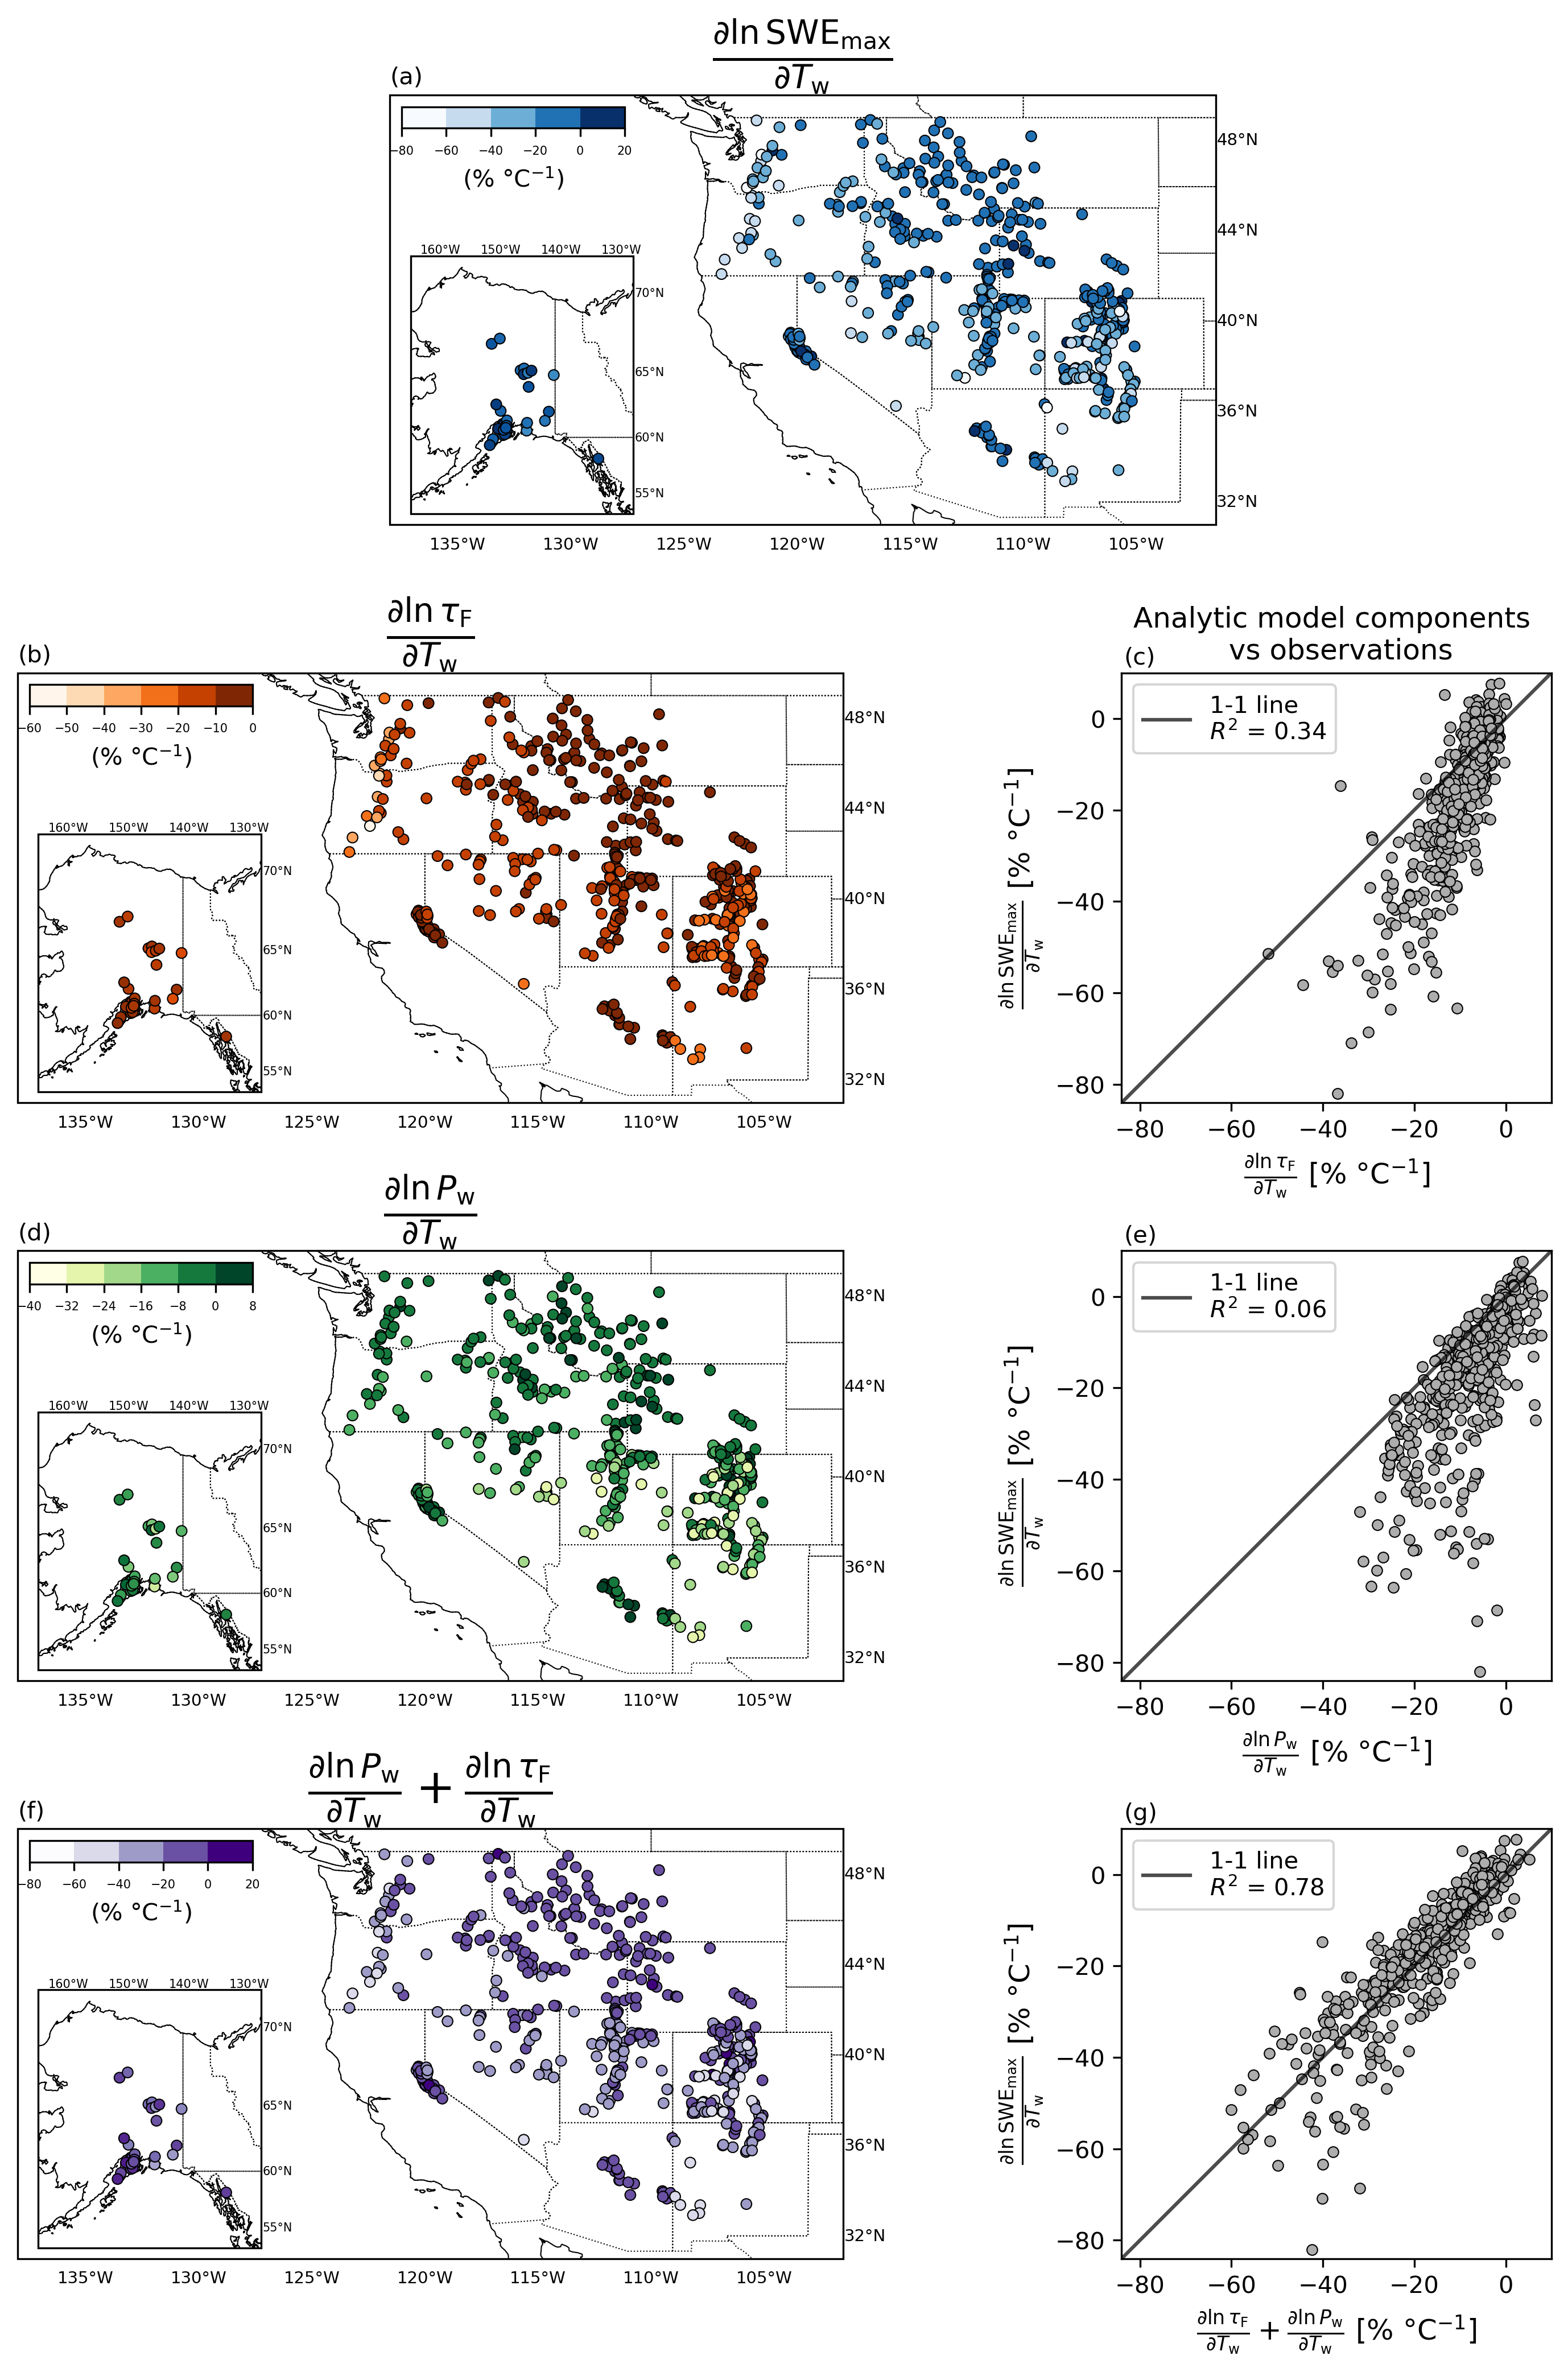

In [59]:
fig = plt.figure(figsize=(10,14),dpi=300)
gs = GridSpec(4, 2, width_ratios=[1.55,1])

oneoneMin = -84
oneoneMax = 10

#############################################
ax0 = fig.add_subplot(gs[:2], projection=ccrs.PlateCarree())
mapPlotFunction(ax0,dlogSWE_dTw,'Blues',np.arange(-80,40,20),r'$\frac{\partial \ln \text{SWE}_\text{max}}{\partial T_\text{w}}$')
ax0.text(-138,50.5,'(a)')

ax2 = fig.add_subplot(gs[2], projection=ccrs.PlateCarree())
mapPlotFunction(ax2,dlogTauF_dTw,'Oranges',np.arange(-60,10,10),r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}$')
ax2.text(-138,50.5,'(b)')

ax3 = fig.add_subplot(gs[3])
ax3.scatter(dlogTauF_dTw,dlogSWE_dTw,20,c='#adadad',edgecolor='k',linewidth=0.5)
ax3.axis('square')
ax3.set_xlim([oneoneMin,oneoneMax])
ax3.set_ylim([oneoneMin,oneoneMax])
ax3.set_yticks([-80,-60,-40,-20,0])
R2String = fr'$R^2$ = {round(R2_from1to1(dlogTauF_dTw,dlogSWE_dTw),2)}'
ax3.plot(np.arange(oneoneMin,oneoneMax+1),np.arange(oneoneMin,oneoneMax+1),c='k',alpha=.7,label=f'1-1 line \n{R2String}')
ax3.legend()
ax3.set_ylabel(r'$\frac{\partial \ln \text{SWE}_\text{max}}{\partial T_\text{w}}$ [% $\degree$C$^{-1}$]',fontsize=12)
ax3.set_xlabel(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}$ [% $\degree$C$^{-1}$]',fontsize=12)
ax3.set_title('Analytic model components \n vs observations')
ax3.text(-83.5,12,'(c)')

ax4 = fig.add_subplot(gs[4], projection=ccrs.PlateCarree())
mapPlotFunction(ax4,dlogPw_dTw,'YlGn',np.arange(-40,10,8),r'$\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$')
ax4.text(-138,50.5,'(d)')

ax5 = fig.add_subplot(gs[5])
ax5.scatter(dlogPw_dTw,dlogSWE_dTw,20,c='#adadad',edgecolor='k',linewidth=0.5)
ax5.axis('square')
ax5.set_xlim([oneoneMin,oneoneMax])
ax5.set_ylim([oneoneMin,oneoneMax])
ax5.set_yticks([-80,-60,-40,-20,0])
R2String = fr'$R^2$ = {round(R2_from1to1(dlogPw_dTw,dlogSWE_dTw),2)}'
ax5.plot(np.arange(oneoneMin,oneoneMax+1),np.arange(oneoneMin,oneoneMax+1),c='k',alpha=.7,label=f'1-1 line \n{R2String}')
ax5.legend()
ax5.set_ylabel(r'$\frac{\partial \ln \text{SWE}_\text{max}}{\partial T_\text{w}}$ [% $\degree$C$^{-1}$]',fontsize=12)
ax5.set_xlabel(r'$\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$ [% $\degree$C$^{-1}$]',fontsize=12)
ax5.text(-83.5,12,'(e)')

ax6 = fig.add_subplot(gs[6], projection=ccrs.PlateCarree())
mapPlotFunction(ax6,dlogTauF_dTw+dlogPw_dTw,'Purples',np.arange(-80,40,20),r'$\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}+\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}$')
ax6.text(-138,50.5,'(f)')

ax7 = fig.add_subplot(gs[7])
ax7.scatter(dlogTauF_dTw+dlogPw_dTw,dlogSWE_dTw,20,c='#adadad',edgecolor='k',linewidth=0.5)
ax7.axis('square')
ax7.set_xlim([oneoneMin,oneoneMax])
ax7.set_ylim([oneoneMin,oneoneMax])
ax7.set_yticks([-80,-60,-40,-20,0])
R2String = fr'$R^2$ = {round(R2_from1to1(dlogTauF_dTw+dlogPw_dTw,dlogSWE_dTw),2)}'
ax7.plot(np.arange(oneoneMin,oneoneMax+1),np.arange(oneoneMin,oneoneMax+1),c='k',alpha=.7,label=f'1-1 line \n{R2String}')
ax7.legend()
ax7.set_ylabel(r'$\frac{\partial \ln \text{SWE}_\text{max}}{\partial T_\text{w}}$ [% $\degree$C$^{-1}$]',fontsize=12)
ax7.set_xlabel(r'$\frac{\partial \ln \tau_\text{F}}{\partial T_\text{w}}+\frac{\partial \ln P_\text{w}}{\partial T_\text{w}}$ [% $\degree$C$^{-1}$]',fontsize=12)
ax7.text(-83.5,12,'(g)')

plt.tight_layout()

saveFigBool = 1
if saveFigBool:
    plt.savefig('/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_mapSen.pdf')

# Supplement Figure: Distributions
Data computed in sineWave.ipynb. Temperature data is from Berthoud Summit (335).

In [3]:
### Load temperature data ###
pathToLoad = '/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureData'
tempData = np.load(pathToLoad + '/figureSuppDist.npz')

winterInds = tempData['winterInds']
winterTemps = tempData['winterTemps']
compTemps = tempData['compTemps']
allTemps = tempData['allTemps']

In [4]:
groupedByDay = []
for i in range(365):
    specDayOfYear = []
    for j in range(36):
        specDayOfYear = specDayOfYear + [allTemps[i+j*365]]
    groupedByDay = groupedByDay + [specDayOfYear]

In [5]:
meanSeasonalCycle = np.array([np.nanmean(np.array(day)) for day in groupedByDay])
stdDevSeasonalCycle = np.array([np.nanstd(np.array(day)) for day in groupedByDay])

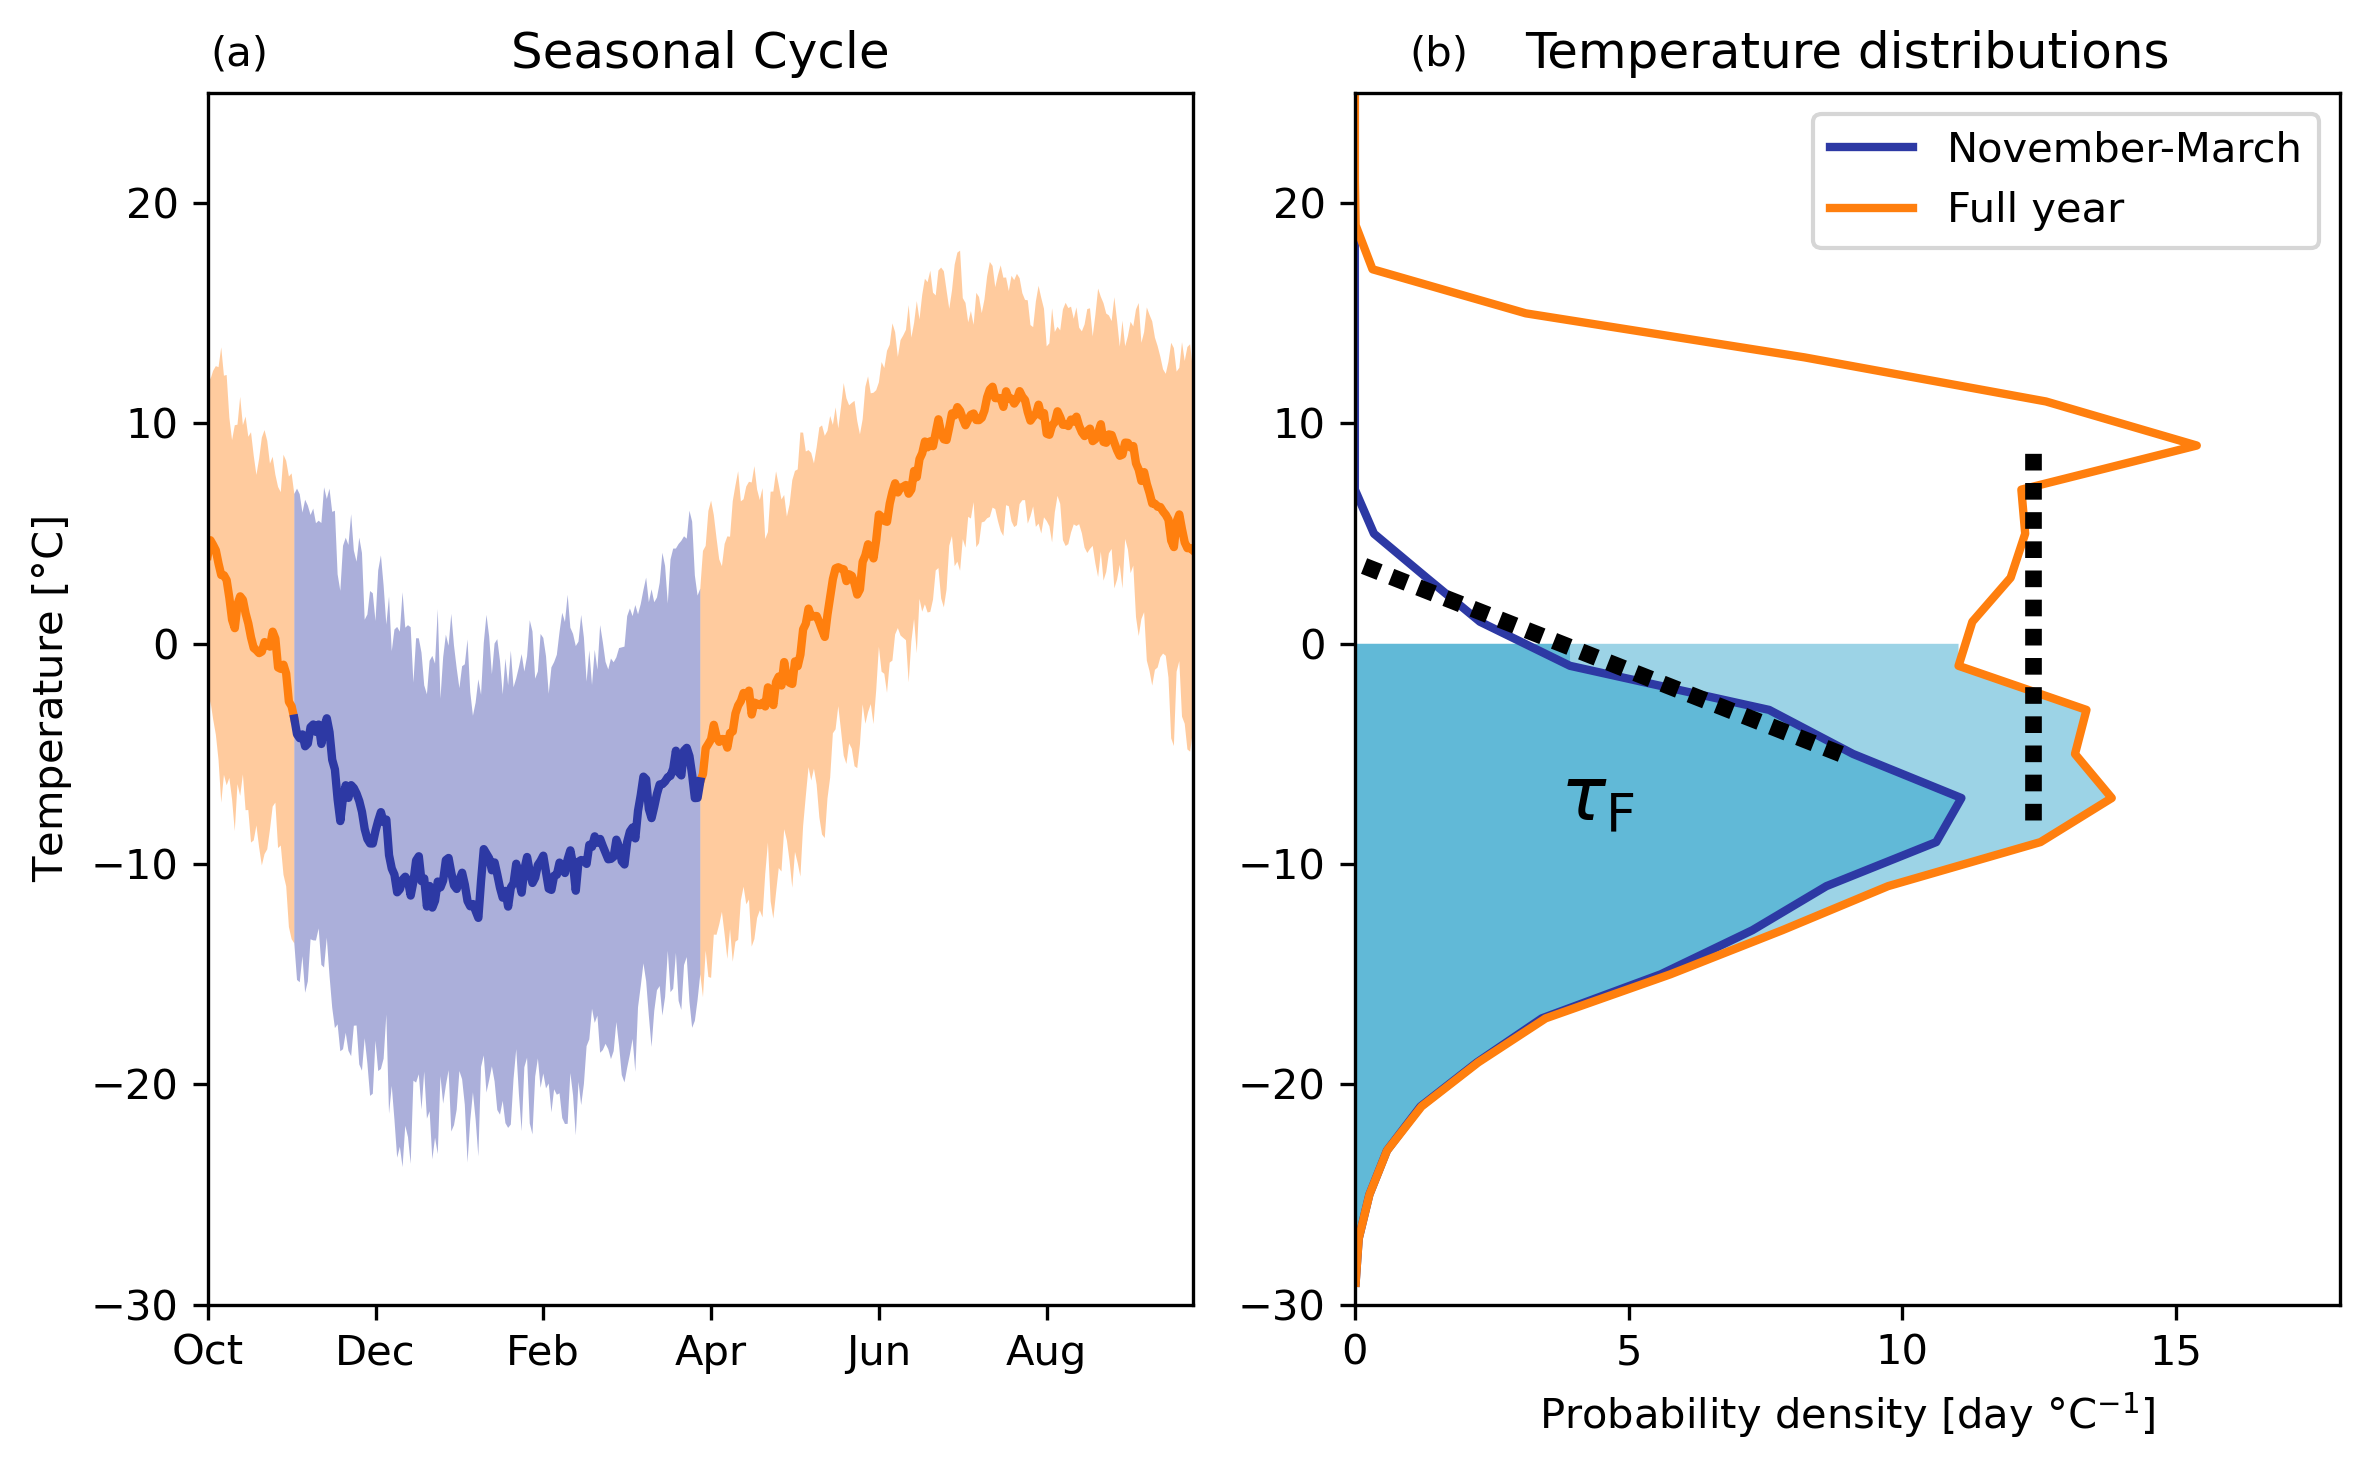

In [74]:
fig = plt.figure(figsize=(8,5),dpi=300)
gs = GridSpec(1,2,width_ratios=[1, 1])

################################
#### Plot of seasonal cycle ####
################################
ax0 = fig.add_subplot(gs[0])


origSeasonalCycle = meanSeasonalCycle
origSTD = stdDevSeasonalCycle
origColor = 'tab:orange'

ts = ax0.plot(np.arange(33),origSeasonalCycle[:33],linewidth=2,c=origColor)
ax0.fill_between(np.arange(33),origSeasonalCycle[:33]-2*origSTD[:33],origSeasonalCycle[:33]+2*origSTD[:33],alpha=.4,facecolor=origColor)
ts = ax0.plot(np.arange(182,365),origSeasonalCycle[182:],linewidth=2,c=origColor)
ax0.fill_between(np.arange(182,365),origSeasonalCycle[182:]-2*origSTD[182:],origSeasonalCycle[182:]+2*origSTD[182:],alpha=.4,facecolor=origColor)

winterColor = '#2D39A4'
ts = ax0.plot(np.arange(32,32+151),origSeasonalCycle[32:32+151],linewidth=2,c=winterColor)
ax0.fill_between(np.arange(32,32+151),origSeasonalCycle[32:32+151]-2*origSTD[32:32+151],origSeasonalCycle[32:32+151]+2*origSTD[32:32+151],alpha=.4,facecolor=winterColor)

#ax0.legend([(box[0], ts[0]),(boxW[0], tsW[0])],
#           [fr'+ {0}$\degree$C ($\pm 2\sigma$)',fr'+ {warmingLevel}$\degree$C ($\pm 2\sigma$)'])
ax0.set_ylim((-30,25))

ax0.set_ylabel(r'Temperature [$\degree$C]')

ax0.set_xlim([0,364])
ax0.set_xticks(np.arange(0,359,62))
ax0.set_xticklabels(['Oct','Dec','Feb','Apr','Jun','Aug'],rotation=0)
ax0.set_title('Seasonal Cycle')

ax0.text(1,26.25,'(a)')

###############################
#### Plot of distributions ####
###############################

## Gaussian (winter temperature distribution) ##
ax1 = fig.add_subplot(gs[1])
# kernelDensityEstimate = kde1d(winterTemps[~np.isnan(winterTemps)],n=128,limits=(-30,20))
# pdf = kernelDensityEstimate[:,1]
# domain = kernelDensityEstimate[:,0]
# bins = np.arange(-30,27,2)
pdf,binEdges = np.histogram(winterTemps[~np.isnan(winterTemps)], bins, density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2
zeroLine = np.zeros(binCenters.size)
ax1.plot(pdf*151,binCenters,linewidth=2,label='November-March',c=winterColor)
ax1.fill_between(pdf*151,zeroLine,binCenters,alpha=.4,where=(zeroLine > binCenters),facecolor='#0992C2')

flatStart = -5
flatEnd = 5
flDomain = np.arange(flatStart,flatEnd+1)
slope,inter = np.polyfit(binCenters[np.logical_and(binCenters>flatStart,binCenters<flatEnd)],
                         pdf[np.logical_and(binCenters>flatStart,binCenters<flatEnd)]*151,1)
ax1.plot(slope*flDomain+inter,
         flDomain,
        c='k',linestyle=(0, (1, .75)),linewidth=4)

## Sinusoid ##
# kernelDensityEstimate = kde1d(allTemps[~np.isnan(allTemps)],n=128,limits=(-30,20))
# pdf = kernelDensityEstimate[:,1]
# domain = kernelDensityEstimate[:,0]
pdf,binEdges = np.histogram(allTemps[~np.isnan(allTemps)], bins, density=True)
binCenters = (binEdges[:-1]+binEdges[1:])/2
ax1.plot(pdf*365,binCenters,linewidth=2,label='Full year',c=origColor)
ax1.fill_between(pdf*365,zeroLine,binCenters,alpha=.4,where=(zeroLine > binCenters),facecolor='#0992C2')

flatStart = -8
flatEnd = 9
flDomain = np.arange(flatStart,flatEnd+1)
ax1.plot(np.ones(flDomain.shape)*np.mean(pdf[np.logical_and(binCenters>flatStart,binCenters<flatEnd)])*365,
         flDomain,
        c='k',linestyle=(0, (1,.75)),linewidth=4)


ax1.set_ylim(-30,25)
ax1.set_xlim(0,18)
ax1.set_title('Temperature distributions')
ax1.set_xlabel('Probability density [day $\degree$C$^{-1}$]')

ax1.legend()
ax1.text(3.75,-8,r'$\tau_\text{F}$',zorder=1,fontsize=18)
ax1.text(1,26.25,'(b)')

# ax1.axvline(flatStart,linestyle=':',c='#8d8d8d')
# ax1.axvline(flatEnd,linestyle=':',c='#8d8d8d')

plt.tight_layout()

saveFigBool = 1
if saveFigBool:
    plt.savefig('/home/nicknish/snowpack/snotelAnalysis/finalizedFigures/figureSupp_distsLin.pdf')

In [51]:
zeroLine = np.zeros(binCenters.size)

In [52]:
zeroLine

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])